# HEART: Hierarchical Embedding for Affective and Riemannian Trajectories

### Case 1: Using the last 30s of recordings

Processing 1.mat (80 trials)...
Processing 2.mat (80 trials)...
Processing 3.mat (80 trials)...
Processing 4.mat (80 trials)...
Processing 5.mat (80 trials)...
Processing 6.mat (80 trials)...
Processing 7.mat (80 trials)...
Processing 8.mat (80 trials)...
Processing 9.mat (80 trials)...
Processing 10.mat (80 trials)...
Processing 11.mat (80 trials)...
Processing 12.mat (80 trials)...
Processing 13.mat (80 trials)...
Processing 14.mat (80 trials)...
Processing 15.mat (80 trials)...
Processing 16.mat (80 trials)...
Processing 17.mat (80 trials)...
Processing 18.mat (80 trials)...
Processing 19.mat (80 trials)...
Processing 20.mat (80 trials)...

Segment boundaries (seconds) for each emotion [last 30 s only]:
Happy    : Mean boundary = 14.64s ± 8.62s | Avg # boundaries = 1.71 (240 trials)
Neutral  : Mean boundary = 14.84s ± 8.10s | Avg # boundaries = 1.82 (160 trials)
Disgust  : Mean boundary = 15.32s ± 8.44s | Avg # boundaries = 1.81 (240 trials)
Sad      : Mean boundary = 15.46s ± 8.98s

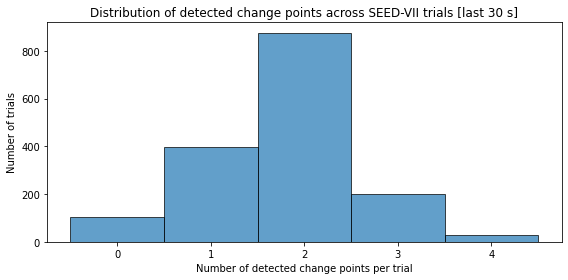


Estimated optimal number of change points per trial ≈ 2


In [4]:
import os
import numpy as np
from collections import defaultdict
from sklearn.covariance import OAS
import scipy.io
import matplotlib.pyplot as plt

# === Configuration ===
fs = 200  # Hz
window_sec = 1
window_samples = fs * window_sec
last_sec = 30  # use only last 30 seconds
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED-VII\Preprocessed_EEG"

# === Emotion label order (80 videos total) ===
seedvii_labels = [
    # Session 1 (1–20)
    "Happy","Neutral","Disgust","Sad","Anger","Anger","Sad","Disgust","Neutral","Happy",
    "Happy","Neutral","Disgust","Sad","Anger","Anger","Sad","Disgust","Neutral","Happy",
    # Session 2 (21–40)
    "Anger","Sad","Fear","Neutral","Surprise","Surprise","Neutral","Fear","Sad","Anger",
    "Anger","Sad","Fear","Neutral","Surprise","Surprise","Neutral","Fear","Sad","Anger",
    # Session 3 (41–60)
    "Happy","Surprise","Disgust","Fear","Anger","Anger","Fear","Disgust","Surprise","Happy",
    "Happy","Surprise","Disgust","Fear","Anger","Anger","Fear","Disgust","Surprise","Happy",
    # Session 4 (61–80)
    "Disgust","Sad","Fear","Surprise","Happy","Happy","Surprise","Fear","Sad","Disgust",
    "Disgust","Sad","Fear","Surprise","Happy","Happy","Surprise","Fear","Sad","Disgust"
]

# === Helper functions ===
def compute_covariance_oas(X):
    """Compute robust covariance (OAS) for EEG window."""
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])  # stability
    return cov

def extract_cov_features(eeg_trial, window_samples):
    """Extract upper-triangular covariance features for each 1s window."""
    n_channels, n_samples = eeg_trial.shape
    n_windows = n_samples // window_samples
    features = []
    for w in range(n_windows):
        start = w * window_samples
        end = start + window_samples
        segment = eeg_trial[:, start:end]
        cov = compute_covariance_oas(segment)
        iu = np.triu_indices(n_channels)
        features.append(cov[iu])
    return np.array(features)

def find_change_points(features, threshold_std=2.0, max_points=6):
    """Detect significant feature-change points using threshold on ΔF."""
    if len(features) < 2:
        return np.array([])

    distances = np.linalg.norm(np.diff(features, axis=0), axis=1)
    threshold = np.mean(distances) + threshold_std * np.std(distances)
    change_idxs = np.where(distances > threshold)[0] + 1
    return change_idxs[:max_points]

# === Main processing ===
emotion_boundaries = defaultdict(list)
change_point_counts = defaultdict(list)

for filename in sorted(os.listdir(data_dir), key=lambda x: int(os.path.splitext(x)[0])):
    if not filename.endswith(".mat"):
        continue

    mat_path = os.path.join(data_dir, filename)
    mat_data = scipy.io.loadmat(mat_path)
    
    # find EEG trial keys
    trial_keys = [k for k in mat_data.keys() if k.isdigit()]
    trial_keys = sorted(trial_keys, key=lambda x: int(x))

    print(f"Processing {filename} ({len(trial_keys)} trials)...")

    for idx, key in enumerate(trial_keys):
        eeg_trial = np.squeeze(mat_data[key])  # shape: (n_channels, n_samples)
        if eeg_trial.ndim != 2:
            continue  # skip malformed trials

        emotion = seedvii_labels[idx]

        # --- use only last 30 seconds ---
        last_30s_samples = last_sec * fs
        if eeg_trial.shape[1] > last_30s_samples:
            eeg_trial = eeg_trial[:, -last_30s_samples:]

        # --- feature extraction & change-point detection ---
        features = extract_cov_features(eeg_trial, window_samples)
        change_idxs = find_change_points(features, threshold_std=2.0, max_points=5)

        emotion_boundaries[emotion].extend(change_idxs * window_sec)
        change_point_counts[emotion].append(len(change_idxs))

# === Summary statistics ===
print("\nSegment boundaries (seconds) for each emotion [last 30 s only]:")
for emotion, boundaries in emotion_boundaries.items():
    avg_b = np.mean(boundaries) if boundaries else 0
    std_b = np.std(boundaries) if boundaries else 0
    avg_n = np.mean(change_point_counts[emotion])
    print(f"{emotion:9s}: Mean boundary = {avg_b:.2f}s ± {std_b:.2f}s | "
          f"Avg # boundaries = {avg_n:.2f} ({len(change_point_counts[emotion])} trials)")

# === Visualization ===
all_counts = []
all_emotions = []
for emotion, counts in change_point_counts.items():
    all_counts.extend(counts)
    all_emotions.extend([emotion] * len(counts))

plt.figure(figsize=(8,4))
plt.hist(all_counts, bins=np.arange(0, max(all_counts)+2)-0.5, edgecolor='black', alpha=0.7)
plt.xlabel("Number of detected change points per trial")
plt.ylabel("Number of trials")
plt.title("Distribution of detected change points across SEED-VII trials [last 30 s]")
plt.xticks(range(int(max(all_counts))+1))
plt.tight_layout()
plt.show()

# === Optimal number estimation ===
optimal_n = int(np.median(all_counts))
print(f"\nEstimated optimal number of change points per trial ≈ {optimal_n}")

In [5]:
import os
import numpy as np
from collections import defaultdict
from sklearn.covariance import OAS
import scipy.io

# --- Configuration ---
fs = 200  # Hz
window_sec = 1
window_samples = fs * window_sec
last_sec = 30  # Use only last 30s of each trial
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED-VII\Preprocessed_EEG"

# --- Emotion labels for SEED-VII ---
seedvii_labels = [
    # Session 1 (1–20)
    "Happy","Neutral","Disgust","Sad","Anger","Anger","Sad","Disgust","Neutral","Happy",
    "Happy","Neutral","Disgust","Sad","Anger","Anger","Sad","Disgust","Neutral","Happy",
    # Session 2 (21–40)
    "Anger","Sad","Fear","Neutral","Surprise","Surprise","Neutral","Fear","Sad","Anger",
    "Anger","Sad","Fear","Neutral","Surprise","Surprise","Neutral","Fear","Sad","Anger",
    # Session 3 (41–60)
    "Happy","Surprise","Disgust","Fear","Anger","Anger","Fear","Disgust","Surprise","Happy",
    "Happy","Surprise","Disgust","Fear","Anger","Anger","Fear","Disgust","Surprise","Happy",
    # Session 4 (61–80)
    "Disgust","Sad","Fear","Surprise","Happy","Happy","Surprise","Fear","Sad","Disgust",
    "Disgust","Sad","Fear","Surprise","Happy","Happy","Surprise","Fear","Sad","Disgust"
]

# --- Helper functions ---
def compute_covariance_oas(X):
    """Compute robust covariance using OAS."""
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])
    return cov

def extract_cov_features(eeg_trial, window_samples):
    """Extract covariance-based EEG features for each 1s window."""
    n_channels, n_samples = eeg_trial.shape
    n_windows = n_samples // window_samples
    features = []
    for w in range(n_windows):
        start = w * window_samples
        end = start + window_samples
        segment = eeg_trial[:, start:end]
        cov = compute_covariance_oas(segment)
        iu = np.triu_indices(n_channels)
        features.append(cov[iu])
    return np.array(features)

def find_multiple_change_points(features, threshold_std=2.0, max_points=2):
    """Find multiple significant change points in features."""
    if len(features) < 2:
        return np.array([])
    
    distances = np.linalg.norm(np.diff(features, axis=0), axis=1)
    threshold = np.mean(distances) + threshold_std * np.std(distances)
    change_idxs = np.where(distances > threshold)[0] + 1  # indices of changes
    return change_idxs[:max_points]

# --- Main processing ---
emotion_boundaries = defaultdict(list)

for filename in sorted(os.listdir(data_dir), key=lambda x: int(os.path.splitext(x)[0])):
    if not filename.endswith(".mat"):
        continue

    mat_path = os.path.join(data_dir, filename)
    mat_data = scipy.io.loadmat(mat_path)

    # SEED-VII uses numeric trial keys: '1', '2', ..., '80'
    trial_keys = [k for k in mat_data.keys() if k.isdigit()]
    trial_keys = sorted(trial_keys, key=lambda x: int(x))

    print(f"Processing {filename} ({len(trial_keys)} trials)...")

    for idx, key in enumerate(trial_keys):
        eeg_trial = np.squeeze(mat_data[key])
        if eeg_trial.ndim != 2:
            continue  # skip malformed trial

        emotion = seedvii_labels[idx]

        # --- Use only the last 30 seconds ---
        last_samples = last_sec * fs
        if eeg_trial.shape[1] > last_samples:
            eeg_trial = eeg_trial[:, -last_samples:]

        # --- Feature extraction and change-point detection ---
        features = extract_cov_features(eeg_trial, window_samples)
        change_points = find_multiple_change_points(features, threshold_std=2.0, max_points=2)

        if len(change_points) > 0:
            emotion_boundaries[emotion].append(change_points * window_sec)

# --- Aggregate across trials ---
print("\nAverage boundary positions (seconds) per emotion [last 30 s only]:\n")

for emotion, all_boundaries in emotion_boundaries.items():
    all_boundaries = [np.array(b) for b in all_boundaries if len(b) > 0]
    if not all_boundaries:
        continue
    max_points = max(len(b) for b in all_boundaries)
    
    print(f"{emotion}:")
    for i in range(max_points):
        valid_points = [b[i] for b in all_boundaries if len(b) > i]
        if len(valid_points) == 0:
            continue
        avg_b = np.mean(valid_points)
        std_b = np.std(valid_points)
        print(f"  Boundary {i+1}: {avg_b:.2f} ± {std_b:.2f} s ({len(valid_points)} trials)")
    print()

Processing 1.mat (80 trials)...
Processing 2.mat (80 trials)...
Processing 3.mat (80 trials)...
Processing 4.mat (80 trials)...
Processing 5.mat (80 trials)...
Processing 6.mat (80 trials)...
Processing 7.mat (80 trials)...
Processing 8.mat (80 trials)...
Processing 9.mat (80 trials)...
Processing 10.mat (80 trials)...
Processing 11.mat (80 trials)...
Processing 12.mat (80 trials)...
Processing 13.mat (80 trials)...
Processing 14.mat (80 trials)...
Processing 15.mat (80 trials)...
Processing 16.mat (80 trials)...
Processing 17.mat (80 trials)...
Processing 18.mat (80 trials)...
Processing 19.mat (80 trials)...
Processing 20.mat (80 trials)...

Average boundary positions (seconds) per emotion [last 30 s only]:

Happy:
  Boundary 1: 13.72 ± 8.75 s (223 trials)
  Boundary 2: 15.49 ± 8.47 s (158 trials)

Neutral:
  Boundary 1: 13.40 ± 7.85 s (146 trials)
  Boundary 2: 15.32 ± 7.95 s (115 trials)

Disgust:
  Boundary 1: 14.30 ± 8.62 s (229 trials)
  Boundary 2: 16.48 ± 8.24 s (172 trials)



In [7]:
import re
import os
import pickle
import numpy as np
import scipy.io
from sklearn.covariance import OAS
from scipy.linalg import logm
import mne

# -----------------------------------------------------------
# Configuration
# -----------------------------------------------------------
fs = 200  # Hz
last_sec = 30  # Use only the last 30 seconds
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED-VII\Preprocessed_EEG"
output_path = "seedvii_features_multi_last30s_preprocessed.pkl"

# -----------------------------------------------------------
# Emotion label order (80 videos total)
# -----------------------------------------------------------
seedvii_labels = [
    # Session 1 (1–20)
    "Happy","Neutral","Disgust","Sad","Anger","Anger","Sad","Disgust","Neutral","Happy",
    "Happy","Neutral","Disgust","Sad","Anger","Anger","Sad","Disgust","Neutral","Happy",
    # Session 2 (21–40)
    "Anger","Sad","Fear","Neutral","Surprise","Surprise","Neutral","Fear","Sad","Anger",
    "Anger","Sad","Fear","Neutral","Surprise","Surprise","Neutral","Fear","Sad","Anger",
    # Session 3 (41–60)
    "Happy","Surprise","Disgust","Fear","Anger","Anger","Fear","Disgust","Surprise","Happy",
    "Happy","Surprise","Disgust","Fear","Anger","Anger","Fear","Disgust","Surprise","Happy",
    # Session 4 (61–80)
    "Disgust","Sad","Fear","Surprise","Happy","Happy","Surprise","Fear","Sad","Disgust",
    "Disgust","Sad","Fear","Surprise","Happy","Happy","Surprise","Fear","Sad","Disgust"
]

# -----------------------------------------------------------
# Emotion-specific mean boundaries (from your output)
# -----------------------------------------------------------
emotion_mean_boundaries = {
    "Happy":    [13.72, 15.49],
    "Neutral":  [13.40, 15.32],
    "Disgust":  [14.30, 16.48],
    "Sad":      [14.33, 16.24],
    "Anger":    [13.61, 15.93],
    "Fear":     [14.93, 16.23],
    "Surprise": [13.64, 15.79]
}

# -----------------------------------------------------------
# Preprocessing parameters
# -----------------------------------------------------------
l_freq, h_freq = 0.05, 47  # Hz
fir_window = 'hamming'
fir_order = 825

# -----------------------------------------------------------
# Utility functions
# -----------------------------------------------------------
def compute_covariance(X):
    """Compute OAS covariance matrix for stability."""
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])
    return cov

def geodesic_distance(C1, C2):
    """Compute Riemannian (geodesic) distance between covariance matrices."""
    sqrt_C1 = np.linalg.cholesky(C1)
    inv_sqrt_C1 = np.linalg.inv(sqrt_C1)
    C2_norm = inv_sqrt_C1 @ C2 @ inv_sqrt_C1.T
    log_C2_norm = logm(C2_norm)
    return np.linalg.norm(np.real(log_C2_norm), 'fro')

def tangent_space_features(C, ref=None):
    """Project covariance matrix to tangent space at ref (identity default)."""
    if ref is None:
        ref = np.eye(C.shape[0])
    logm_diff = logm(np.linalg.inv(ref) @ C)
    iu = np.triu_indices_from(logm_diff)
    return np.real(logm_diff[iu])

def extract_multi_boundary_features(eeg_trial, boundaries_sec):
    """Compute features between multiple emotion-based boundaries."""
    n_samples = eeg_trial.shape[1]
    total_time = n_samples / fs

    boundaries = sorted([b for b in boundaries_sec if b < total_time])
    segment_points = [0] + [int(b * fs) for b in boundaries] + [n_samples]

    covs = []
    for i in range(len(segment_points) - 1):
        start, end = segment_points[i], segment_points[i + 1]
        segment = eeg_trial[:, start:end]
        covs.append(compute_covariance(segment))

    distances, speeds = [], []
    for i in range(len(covs) - 1):
        d = geodesic_distance(covs[i], covs[i + 1])
        dt = (segment_points[i + 1] - segment_points[i]) / fs
        speeds.append(d / dt if dt > 0 else 0)
        distances.append(d)

    curvature = np.gradient(distances) if len(distances) > 2 else [0] * len(distances)
    tangent_features = [tangent_space_features(C) for C in covs]

    features = np.concatenate([
        *tangent_features,
        distances,
        speeds,
        curvature
    ])
    return features

# -----------------------------------------------------------
# EEG preprocessing with MNE
# -----------------------------------------------------------
def preprocess_eeg(raw_array, sfreq, ch_names):
    """Bandpass, interpolate, and clean EEG via ICA."""
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
    raw = mne.io.RawArray(raw_array, info, verbose=False)

    # Band-pass filter
    raw.filter(l_freq=l_freq, h_freq=h_freq, fir_window=fir_window, fir_design='firwin',
               l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)

    # ICA for artifact removal
    n_components = min(len(raw.ch_names), 20)
    ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, verbose=False)
    ica.fit(raw)
    eog_indices, _ = ica.find_bads_eog(raw, ch_name=[ch_names[0], ch_names[2]])
    ica.exclude = eog_indices
    ica.apply(raw, verbose=False)

    return raw.get_data()

# -----------------------------------------------------------
# Main processing
# -----------------------------------------------------------
X, y, subjects = [], [], []
mat_files = [f for f in os.listdir(data_dir) if f.endswith(".mat")]
print(f"Found {len(mat_files)} .mat files\n")

for filename in sorted(mat_files, key=lambda x: int(os.path.splitext(x)[0])):
    subject_id = os.path.splitext(filename)[0]
    mat_path = os.path.join(data_dir, filename)

    try:
        mat_data = scipy.io.loadmat(mat_path, simplify_cells=True)
    except TypeError:
        mat_data = scipy.io.loadmat(mat_path)

    # SEED-VII trial keys are '1', '2', ..., '80'
    trial_keys = [k for k in mat_data.keys() if k.isdigit()]
    if not trial_keys:
        print(f"No numeric trial keys found in {filename}, skipping.")
        continue

    trial_keys = sorted(trial_keys, key=lambda x: int(x))
    print(f"Processing {filename}: {len(trial_keys)} trials")

    for idx, key in enumerate(trial_keys):
        if idx >= len(seedvii_labels):
            continue

        eeg_trial = np.squeeze(np.array(mat_data[key]))
        if eeg_trial.ndim != 2:
            print(f"  Skipping {filename} {key} (shape={eeg_trial.shape})")
            continue

        # --- Restrict to last 30 seconds ---
        last_samples = last_sec * fs
        if eeg_trial.shape[1] > last_samples:
            eeg_trial = eeg_trial[:, -last_samples:]

        # --- Preprocess EEG ---
        ch_names = [f'EEG{i+1}' for i in range(eeg_trial.shape[0])]
        try:
            eeg_trial = preprocess_eeg(eeg_trial, sfreq=fs, ch_names=ch_names)
        except Exception as e:
            print(f"  Preprocessing failed for {filename} {key}: {e}")
            continue

        emotion = seedvii_labels[idx]
        if emotion not in emotion_mean_boundaries:
            print(f"  Unknown emotion '{emotion}', skipping.")
            continue

        boundaries = emotion_mean_boundaries[emotion]

        # --- Adjust boundaries for 30s segment ---
        total_time = eeg_trial.shape[1] / fs
        boundaries = [b for b in boundaries if 0 < b < last_sec]

        try:
            features = extract_multi_boundary_features(eeg_trial, boundaries)
            X.append(features)
            y.append(emotion)
            subjects.append(subject_id)
        except Exception as e:
            print(f"  Feature extraction failed for {filename} {key}: {e}")
            continue

# -----------------------------------------------------------
# Save features
# -----------------------------------------------------------
with open(output_path, "wb") as f:
    pickle.dump({"features": X, "labels": y, "subjects": subjects}, f)

subject_counts = {s: subjects.count(s) for s in sorted(set(subjects))}
print(f"\nSaved {len(X)} feature vectors to {output_path}")
print(f"Unique subjects: {len(subject_counts)} → {list(subject_counts.keys())}")
for subj, count in subject_counts.items():
    print(f"  Subject {subj}: {count} trials")

Found 20 .mat files

Processing 1.mat: 80 trials


<ipython-input-7-a313c863b98a>:125: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-7-a313c863b98a>:129: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 for `infomax` and `picard`. The current default of max_iter=200 will be changed to "auto" in version 0.24.
  ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, verbose=False)
<ipython-input-7-a313c863b98a>:125: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-7-a313c863b98a>:129: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 fo

<ipython-input-7-a313c863b98a>:125: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-7-a313c863b98a>:129: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 for `infomax` and `picard`. The current default of max_iter=200 will be changed to "auto" in version 0.24.
  ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, verbose=False)
<ipython-input-7-a313c863b98a>:125: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-7-a313c863b98a>:129: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 fo

<ipython-input-7-a313c863b98a>:125: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-7-a313c863b98a>:129: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 for `infomax` and `picard`. The current default of max_iter=200 will be changed to "auto" in version 0.24.
  ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, verbose=False)
<ipython-input-7-a313c863b98a>:125: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-7-a313c863b98a>:129: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 fo

<ipython-input-7-a313c863b98a>:125: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-7-a313c863b98a>:129: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 for `infomax` and `picard`. The current default of max_iter=200 will be changed to "auto" in version 0.24.
  ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, verbose=False)
<ipython-input-7-a313c863b98a>:125: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-7-a313c863b98a>:129: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 fo

...

<ipython-input-7-a313c863b98a>:125: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-7-a313c863b98a>:129: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 for `infomax` and `picard`. The current default of max_iter=200 will be changed to "auto" in version 0.24.
  ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, verbose=False)
<ipython-input-7-a313c863b98a>:125: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-7-a313c863b98a>:129: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 fo

<ipython-input-7-a313c863b98a>:125: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-7-a313c863b98a>:129: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 for `infomax` and `picard`. The current default of max_iter=200 will be changed to "auto" in version 0.24.
  ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, verbose=False)
<ipython-input-7-a313c863b98a>:125: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-7-a313c863b98a>:129: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 fo

<ipython-input-7-a313c863b98a>:125: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-7-a313c863b98a>:129: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 for `infomax` and `picard`. The current default of max_iter=200 will be changed to "auto" in version 0.24.
  ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, verbose=False)
C:\Users\jonah\AppData\Local\R-MINI~1\envs\gpu2\lib\site-packages\sklearn\decomposition\_fastica.py:120: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  ConvergenceWarning)
<ipython-input-7-a313c863b98a>:125: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or 

<ipython-input-7-a313c863b98a>:129: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 for `infomax` and `picard`. The current default of max_iter=200 will be changed to "auto" in version 0.24.
  ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, verbose=False)
<ipython-input-7-a313c863b98a>:125: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-7-a313c863b98a>:129: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 for `infomax` and `picard`. The current default of max_iter=200 will be changed to "auto" in version 0.24.
  ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, verbose=False)
<ipython-input-7-a313c863b98a>


Saved 1600 feature vectors to seedvii_features_multi_last30s_preprocessed.pkl
Unique subjects: 20 → ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '3', '4', '5', '6', '7', '8', '9']
  Subject 1: 80 trials
  Subject 10: 80 trials
  Subject 11: 80 trials
  Subject 12: 80 trials
  Subject 13: 80 trials
  Subject 14: 80 trials
  Subject 15: 80 trials
  Subject 16: 80 trials
  Subject 17: 80 trials
  Subject 18: 80 trials
  Subject 19: 80 trials
  Subject 2: 80 trials
  Subject 20: 80 trials
  Subject 3: 80 trials
  Subject 4: 80 trials
  Subject 5: 80 trials
  Subject 6: 80 trials
  Subject 7: 80 trials
  Subject 8: 80 trials
  Subject 9: 80 trials


In [10]:
import pickle
import numpy as np

# --------------------------------------------------------
# Load SEED feature data
# --------------------------------------------------------
with open("seedvii_features_multi_last30s_preprocessed.pkl", "rb") as f:
    data = pickle.load(f)

X = data["features"]
y = data["labels"]
subjects = data["subjects"]

# --------------------------------------------------------
# Russell’s Circumplex Model for SEED emotion categories
# --------------------------------------------------------
# Representative VAD (Valence–Arousal–Dominance) coordinates
# Based on typical affective mapping:
#   Positive ≈ Joy (high valence, high arousal, high dominance)
#   Neutral  ≈ Neutral (mid valence, mid arousal, mid dominance)
#   Negative ≈ Sadness (low valence, low arousal, low dominance)
emotion_to_vad = {
    "Anger":       [0.2, 0.9, 0.8],
    "Disgust":     [0.2, 0.6, 0.5],
    "Fear":        [0.1, 0.9, 0.3],
    "Sad":         [0.1, 0.2, 0.3],
    "Neutral":     [0.5, 0.5, 0.5],
    "Happy":       [0.9, 0.9, 0.8],
    "Surprise":    [0.7, 0.8, 0.5]
}

# --------------------------------------------------------
# Build VAD arrays
# --------------------------------------------------------
V, A, D = [], [], []

for emotion in y:
    valence, arousal, dominance = emotion_to_vad.get(emotion, [0.5, 0.5, 0.5])
    V.append(valence)
    A.append(arousal)
    D.append(dominance)

V, A, D = np.array(V), np.array(A), np.array(D)

# --------------------------------------------------------
# Save augmented data
# --------------------------------------------------------
augmented_data = {
    "features": X,
    "labels": y,
    "subjects": subjects,
    "valence": V,
    "arousal": A,
    "dominance": D,
}

output_path = "seedvii_features_multi_last30s_with_vad_preprocessed.pkl"
with open(output_path, "wb") as f:
    pickle.dump(augmented_data, f)

print(f"Saved SEED augmented data with VAD to {output_path}")
print(f"Total samples: {len(X)} | Unique emotions: {set(y)}")

Saved SEED augmented data with VAD to seedvii_features_multi_last30s_with_vad_preprocessed.pkl
Total samples: 1600 | Unique emotions: {'Surprise', 'Disgust', 'Fear', 'Anger', 'Sad', 'Happy', 'Neutral'}


In [11]:
import pickle
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import classification_report

# --------------------------------------------------------
# Load SEED preprocessed feature data
# --------------------------------------------------------
with open("seedvii_features_multi_last30s_with_vad_preprocessed.pkl", "rb") as f:
    data = pickle.load(f)

X = np.array(data["features"])
V = np.array(data["valence"])
A = np.array(data["arousal"])
D = np.array(data["dominance"])
labels = np.array(data["labels"])
subjects = np.array(data["subjects"])

# --------------------------------------------------------
# Encode emotions
# --------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(labels)
n_classes = len(le.classes_)
print(f"Loaded {len(X)} samples from {len(np.unique(subjects))} subjects.")

# --------------------------------------------------------
# Subject-wise 80/20 split
# --------------------------------------------------------
unique_subjects = np.unique(subjects)
train_subjects, test_subjects = train_test_split(
    unique_subjects, test_size=0.2, random_state=42
)
train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
V_train, V_test = V[train_mask], V[test_mask]
A_train, A_test = A[train_mask], A[test_mask]
D_train, D_test = D[train_mask], D[test_mask]
subjects_train = subjects[train_mask]

print(f"Train subjects: {train_subjects}")
print(f"Test subjects : {test_subjects}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# --------------------------------------------------------
# Prepare meta-features via GroupKFold (subject-aware CV)
# --------------------------------------------------------
meta_train = np.zeros((X_train.shape[0], 3 + n_classes))  # [V, A, D] + emotion probs

gkf = GroupKFold(n_splits=5)
fold = 1
for train_idx, val_idx in gkf.split(X_train, y_train, groups=subjects_train):
    print(f"  Fold {fold}: training {len(train_idx)}, validating {len(val_idx)}")
    fold += 1

    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    V_fold_train, V_fold_val = V_train[train_idx], V_train[val_idx]
    A_fold_train, A_fold_val = A_train[train_idx], A_train[val_idx]
    D_fold_train, D_fold_val = D_train[train_idx], D_train[val_idx]

    # Base regressors + classifier
    reg_V = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_A = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_D = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    clf_emotion = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

    reg_V.fit(X_fold_train, V_fold_train)
    reg_A.fit(X_fold_train, A_fold_train)
    reg_D.fit(X_fold_train, D_fold_train)
    clf_emotion.fit(X_fold_train, y_fold_train)

    # Validation predictions for meta-training
    V_pred = reg_V.predict(X_fold_val).reshape(-1, 1)
    A_pred = reg_A.predict(X_fold_val).reshape(-1, 1)
    D_pred = reg_D.predict(X_fold_val).reshape(-1, 1)
    probs = clf_emotion.predict_proba(X_fold_val)

    meta_train[val_idx] = np.hstack([V_pred, A_pred, D_pred, probs])

# --------------------------------------------------------
# Train final base models on full training set
# --------------------------------------------------------
reg_V_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_A_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_D_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
clf_emotion_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

reg_V_final.fit(X_train, V_train)
reg_A_final.fit(X_train, A_train)
reg_D_final.fit(X_train, D_train)
clf_emotion_final.fit(X_train, y_train)

# Test predictions for meta-testing
V_pred_test = reg_V_final.predict(X_test).reshape(-1, 1)
A_pred_test = reg_A_final.predict(X_test).reshape(-1, 1)
D_pred_test = reg_D_final.predict(X_test).reshape(-1, 1)
probs_test = clf_emotion_final.predict_proba(X_test)
meta_test = np.hstack([V_pred_test, A_pred_test, D_pred_test, probs_test])

# --------------------------------------------------------
# Train and evaluate meta-classifier
# --------------------------------------------------------
meta_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
meta_clf.fit(meta_train, y_train)
y_pred_meta = meta_clf.predict(meta_test)

print("\n=== Meta-Classifier Performance (Subject-wise Split) ===\n")
print(classification_report(y_test, y_pred_meta, target_names=le.classes_, digits=3))

Loaded 1600 samples from 20 subjects.
Train subjects: ['17' '14' '2' '12' '8' '6' '3' '11' '18' '9' '13' '20' '16' '19' '4' '15']
Test subjects : ['1' '7' '5' '10']
Train samples: 1280, Test samples: 320
  Fold 1: training 960, validating 320
  Fold 2: training 1040, validating 240
  Fold 3: training 1040, validating 240
  Fold 4: training 1040, validating 240
  Fold 5: training 1040, validating 240

=== Meta-Classifier Performance (Subject-wise Split) ===

              precision    recall  f1-score   support

       Anger      0.920     0.479     0.630        48
     Disgust      0.452     0.292     0.354        48
        Fear      0.697     0.958     0.807        48
       Happy      0.536     0.771     0.632        48
     Neutral      0.176     0.094     0.122        32
         Sad      0.362     0.604     0.453        48
    Surprise      0.469     0.312     0.375        48

    accuracy                          0.522       320
   macro avg      0.516     0.501     0.482       

In [12]:
import pickle
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import classification_report

# --------------------------------------------------------
# Load SEED-VII preprocessed feature data
# --------------------------------------------------------
with open("seedvii_features_multi_last30s_with_vad_preprocessed.pkl", "rb") as f:
    data = pickle.load(f)

X = np.array(data["features"])
V = np.array(data["valence"])
A = np.array(data["arousal"])
D = np.array(data["dominance"])
labels = np.array(data["labels"])
subjects = np.array(data["subjects"])

# --------------------------------------------------------
# Define emotion groups (binary: Positive vs Negative)
# --------------------------------------------------------
positive_emotions = ["Happy", "Surprise"]
negative_emotions = ["Anger", "Disgust", "Sad", "Fear"]

mask = np.isin(labels, positive_emotions + negative_emotions)
X = X[mask]
V = V[mask]
A = A[mask]
D = D[mask]
labels = labels[mask]
subjects = subjects[mask]

# Relabel to binary
binary_labels = np.where(np.isin(labels, positive_emotions), "Positive", "Negative")

# Encode labels
le = LabelEncoder()
y = le.fit_transform(binary_labels)  # 0=Negative, 1=Positive
print(f"Binary Positive vs Negative: {len(X)} samples from {len(np.unique(subjects))} subjects.")

# --------------------------------------------------------
# Subject-wise 80/20 split
# --------------------------------------------------------
unique_subjects = np.unique(subjects)
train_subjects, test_subjects = train_test_split(
    unique_subjects, test_size=0.2, random_state=42
)
train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
V_train, V_test = V[train_mask], V[test_mask]
A_train, A_test = A[train_mask], A[test_mask]
D_train, D_test = D[train_mask], D[test_mask]
subjects_train = subjects[train_mask]

print(f"Train subjects: {train_subjects}")
print(f"Test subjects : {test_subjects}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# --------------------------------------------------------
# Prepare meta-features via GroupKFold (subject-aware CV)
# --------------------------------------------------------
meta_train = np.zeros((X_train.shape[0], 3 + len(np.unique(y_train))))  # [V, A, D] + emotion probs

gkf = GroupKFold(n_splits=5)
fold = 1
for train_idx, val_idx in gkf.split(X_train, y_train, groups=subjects_train):
    print(f"  Fold {fold}: training {len(train_idx)}, validating {len(val_idx)}")
    fold += 1

    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    V_fold_train, V_fold_val = V_train[train_idx], V_train[val_idx]
    A_fold_train, A_fold_val = A_train[train_idx], A_train[val_idx]
    D_fold_train, D_fold_val = D_train[train_idx], D_train[val_idx]

    # Base regressors + classifier
    reg_V = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_A = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_D = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    clf_emotion = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

    reg_V.fit(X_fold_train, V_fold_train)
    reg_A.fit(X_fold_train, A_fold_train)
    reg_D.fit(X_fold_train, D_fold_train)
    clf_emotion.fit(X_fold_train, y_fold_train)

    # Validation predictions for meta-training
    V_pred = reg_V.predict(X_fold_val).reshape(-1, 1)
    A_pred = reg_A.predict(X_fold_val).reshape(-1, 1)
    D_pred = reg_D.predict(X_fold_val).reshape(-1, 1)
    probs = clf_emotion.predict_proba(X_fold_val)

    meta_train[val_idx] = np.hstack([V_pred, A_pred, D_pred, probs])

# --------------------------------------------------------
# Train final base models on full training set
# --------------------------------------------------------
reg_V_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_A_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_D_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
clf_emotion_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

reg_V_final.fit(X_train, V_train)
reg_A_final.fit(X_train, A_train)
reg_D_final.fit(X_train, D_train)
clf_emotion_final.fit(X_train, y_train)

# Test predictions for meta-testing
V_pred_test = reg_V_final.predict(X_test).reshape(-1, 1)
A_pred_test = reg_A_final.predict(X_test).reshape(-1, 1)
D_pred_test = reg_D_final.predict(X_test).reshape(-1, 1)
probs_test = clf_emotion_final.predict_proba(X_test)
meta_test = np.hstack([V_pred_test, A_pred_test, D_pred_test, probs_test])

# --------------------------------------------------------
# Train and evaluate meta-classifier
# --------------------------------------------------------
meta_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
meta_clf.fit(meta_train, y_train)
y_pred_meta = meta_clf.predict(meta_test)

print("\n=== Meta-Classifier Performance (Positive vs Negative, SEED-VII) ===\n")
print(classification_report(y_test, y_pred_meta, target_names=le.classes_, digits=3))

Binary Positive vs Negative: 1440 samples from 20 subjects.
Train subjects: ['17' '14' '2' '12' '8' '6' '3' '11' '18' '9' '13' '20' '16' '19' '4' '15']
Test subjects : ['1' '7' '5' '10']
Train samples: 1152, Test samples: 288
  Fold 1: training 864, validating 288
  Fold 2: training 936, validating 216
  Fold 3: training 936, validating 216
  Fold 4: training 936, validating 216
  Fold 5: training 936, validating 216

=== Meta-Classifier Performance (Positive vs Negative, SEED-VII) ===

              precision    recall  f1-score   support

    Negative      0.748     0.865     0.802       192
    Positive      0.606     0.417     0.494        96

    accuracy                          0.715       288
   macro avg      0.677     0.641     0.648       288
weighted avg      0.701     0.715     0.699       288



### Case 2: Using full recordings

Processing 1.mat (80 trials)...
Processing 2.mat (80 trials)...
Processing 3.mat (80 trials)...
Processing 4.mat (80 trials)...
Processing 5.mat (80 trials)...
Processing 6.mat (80 trials)...
Processing 7.mat (80 trials)...
Processing 8.mat (80 trials)...
Processing 9.mat (80 trials)...
Processing 10.mat (80 trials)...
Processing 11.mat (80 trials)...
Processing 12.mat (80 trials)...
Processing 13.mat (80 trials)...
Processing 14.mat (80 trials)...
Processing 15.mat (80 trials)...
Processing 16.mat (80 trials)...
Processing 17.mat (80 trials)...
Processing 18.mat (80 trials)...
Processing 19.mat (80 trials)...
Processing 20.mat (80 trials)...

Segment boundaries (seconds) for each emotion [full trial]:
Happy    : Mean boundary = 48.50s ± 44.92s | Avg # boundaries = 4.10 (240 trials)
Neutral  : Mean boundary = 53.91s ± 48.73s | Avg # boundaries = 4.30 (160 trials)
Disgust  : Mean boundary = 53.87s ± 47.96s | Avg # boundaries = 4.55 (240 trials)
Sad      : Mean boundary = 70.35s ± 57.38s

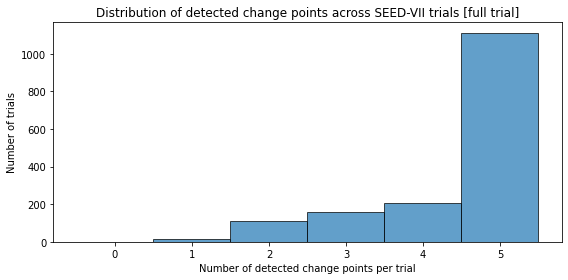


Estimated optimal number of change points per trial ≈ 5


In [1]:
import os
import numpy as np
from collections import defaultdict
from sklearn.covariance import OAS
import scipy.io
import matplotlib.pyplot as plt

# === Configuration ===
fs = 200  # Hz
window_sec = 1
window_samples = fs * window_sec
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED-VII\Preprocessed_EEG"

# === Emotion label order (80 videos total) ===
seedvii_labels = [
    # Session 1 (1–20)
    "Happy","Neutral","Disgust","Sad","Anger","Anger","Sad","Disgust","Neutral","Happy",
    "Happy","Neutral","Disgust","Sad","Anger","Anger","Sad","Disgust","Neutral","Happy",
    # Session 2 (21–40)
    "Anger","Sad","Fear","Neutral","Surprise","Surprise","Neutral","Fear","Sad","Anger",
    "Anger","Sad","Fear","Neutral","Surprise","Surprise","Neutral","Fear","Sad","Anger",
    # Session 3 (41–60)
    "Happy","Surprise","Disgust","Fear","Anger","Anger","Fear","Disgust","Surprise","Happy",
    "Happy","Surprise","Disgust","Fear","Anger","Anger","Fear","Disgust","Surprise","Happy",
    # Session 4 (61–80)
    "Disgust","Sad","Fear","Surprise","Happy","Happy","Surprise","Fear","Sad","Disgust",
    "Disgust","Sad","Fear","Surprise","Happy","Happy","Surprise","Fear","Sad","Disgust"
]

# === Helper functions ===
def compute_covariance_oas(X):
    """Compute robust covariance (OAS) for EEG window."""
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])  # stability
    return cov

def extract_cov_features(eeg_trial, window_samples):
    """Extract upper-triangular covariance features for each 1s window."""
    n_channels, n_samples = eeg_trial.shape
    n_windows = n_samples // window_samples
    features = []
    for w in range(n_windows):
        start = w * window_samples
        end = start + window_samples
        segment = eeg_trial[:, start:end]
        cov = compute_covariance_oas(segment)
        iu = np.triu_indices(n_channels)
        features.append(cov[iu])
    return np.array(features)

def find_change_points(features, threshold_std=2.0, max_points=6):
    """Detect significant feature-change points using threshold on ΔF."""
    if len(features) < 2:
        return np.array([])

    distances = np.linalg.norm(np.diff(features, axis=0), axis=1)
    threshold = np.mean(distances) + threshold_std * np.std(distances)
    change_idxs = np.where(distances > threshold)[0] + 1
    return change_idxs[:max_points]

# === Main processing ===
emotion_boundaries = defaultdict(list)
change_point_counts = defaultdict(list)

for filename in sorted(os.listdir(data_dir), key=lambda x: int(os.path.splitext(x)[0])):
    if not filename.endswith(".mat"):
        continue

    mat_path = os.path.join(data_dir, filename)
    mat_data = scipy.io.loadmat(mat_path)
    
    # find EEG trial keys
    trial_keys = [k for k in mat_data.keys() if k.isdigit()]
    trial_keys = sorted(trial_keys, key=lambda x: int(x))

    print(f"Processing {filename} ({len(trial_keys)} trials)...")

    for idx, key in enumerate(trial_keys):
        eeg_trial = np.squeeze(mat_data[key])  # shape: (n_channels, n_samples)
        if eeg_trial.ndim != 2:
            continue  # skip malformed trials

        emotion = seedvii_labels[idx]

        # --- feature extraction & change-point detection on full trial ---
        features = extract_cov_features(eeg_trial, window_samples)
        change_idxs = find_change_points(features, threshold_std=2.0, max_points=5)

        emotion_boundaries[emotion].extend(change_idxs * window_sec)
        change_point_counts[emotion].append(len(change_idxs))

# === Summary statistics ===
print("\nSegment boundaries (seconds) for each emotion [full trial]:")
for emotion, boundaries in emotion_boundaries.items():
    avg_b = np.mean(boundaries) if boundaries else 0
    std_b = np.std(boundaries) if boundaries else 0
    avg_n = np.mean(change_point_counts[emotion])
    print(f"{emotion:9s}: Mean boundary = {avg_b:.2f}s ± {std_b:.2f}s | "
          f"Avg # boundaries = {avg_n:.2f} ({len(change_point_counts[emotion])} trials)")

# === Visualization ===
all_counts = []
all_emotions = []
for emotion, counts in change_point_counts.items():
    all_counts.extend(counts)
    all_emotions.extend([emotion] * len(counts))

plt.figure(figsize=(8,4))
plt.hist(all_counts, bins=np.arange(0, max(all_counts)+2)-0.5, edgecolor='black', alpha=0.7)
plt.xlabel("Number of detected change points per trial")
plt.ylabel("Number of trials")
plt.title("Distribution of detected change points across SEED-VII trials [full trial]")
plt.xticks(range(int(max(all_counts))+1))
plt.tight_layout()
plt.show()

# === Optimal number estimation ===
optimal_n = int(np.median(all_counts))
print(f"\nEstimated optimal number of change points per trial ≈ {optimal_n}")

In [5]:
import os
import numpy as np
from collections import defaultdict
from sklearn.covariance import OAS
import scipy.io

# --- Configuration ---
fs = 200  # Hz
window_sec = 1
window_samples = fs * window_sec
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED-VII\Preprocessed_EEG"

# --- Emotion labels for SEED-VII ---
seedvii_labels = [
    # Session 1 (1–20)
    "Happy","Neutral","Disgust","Sad","Anger","Anger","Sad","Disgust","Neutral","Happy",
    "Happy","Neutral","Disgust","Sad","Anger","Anger","Sad","Disgust","Neutral","Happy",
    # Session 2 (21–40)
    "Anger","Sad","Fear","Neutral","Surprise","Surprise","Neutral","Fear","Sad","Anger",
    "Anger","Sad","Fear","Neutral","Surprise","Surprise","Neutral","Fear","Sad","Anger",
    # Session 3 (41–60)
    "Happy","Surprise","Disgust","Fear","Anger","Anger","Fear","Disgust","Surprise","Happy",
    "Happy","Surprise","Disgust","Fear","Anger","Anger","Fear","Disgust","Surprise","Happy",
    # Session 4 (61–80)
    "Disgust","Sad","Fear","Surprise","Happy","Happy","Surprise","Fear","Sad","Disgust",
    "Disgust","Sad","Fear","Surprise","Happy","Happy","Surprise","Fear","Sad","Disgust"
]

# --- Helper functions ---
def compute_covariance_oas(X):
    """Compute robust covariance using OAS."""
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])
    return cov

def extract_cov_features(eeg_trial, window_samples):
    """Extract covariance-based EEG features for each 1s window."""
    n_channels, n_samples = eeg_trial.shape
    n_windows = n_samples // window_samples
    features = []
    for w in range(n_windows):
        start = w * window_samples
        end = start + window_samples
        segment = eeg_trial[:, start:end]
        cov = compute_covariance_oas(segment)
        iu = np.triu_indices(n_channels)
        features.append(cov[iu])
    return np.array(features)

def find_multiple_change_points(features, threshold_std=2.0, max_points=2):
    """Find multiple significant change points in features."""
    if len(features) < 2:
        return np.array([])
    
    distances = np.linalg.norm(np.diff(features, axis=0), axis=1)
    threshold = np.mean(distances) + threshold_std * np.std(distances)
    change_idxs = np.where(distances > threshold)[0] + 1  # indices of changes
    return change_idxs[:max_points]

# --- Main processing ---
emotion_boundaries = defaultdict(list)

for filename in sorted(os.listdir(data_dir), key=lambda x: int(os.path.splitext(x)[0])):
    if not filename.endswith(".mat"):
        continue

    mat_path = os.path.join(data_dir, filename)
    mat_data = scipy.io.loadmat(mat_path)

    # SEED-VII uses numeric trial keys: '1', '2', ..., '80'
    trial_keys = [k for k in mat_data.keys() if k.isdigit()]
    trial_keys = sorted(trial_keys, key=lambda x: int(x))

    print(f"Processing {filename} ({len(trial_keys)} trials)...")

    for idx, key in enumerate(trial_keys):
        eeg_trial = np.squeeze(mat_data[key])
        if eeg_trial.ndim != 2:
            continue  # skip malformed trial

        emotion = seedvii_labels[idx]

        # --- Use full EEG trial (no truncation) ---
        features = extract_cov_features(eeg_trial, window_samples)
        change_points = find_multiple_change_points(features, threshold_std=2.0, max_points=5)

        if len(change_points) > 0:
            emotion_boundaries[emotion].append(change_points * window_sec)

# --- Aggregate across trials ---
print("\nAverage boundary positions (seconds) per emotion [full trial]:\n")

for emotion, all_boundaries in emotion_boundaries.items():
    all_boundaries = [np.array(b) for b in all_boundaries if len(b) > 0]
    if not all_boundaries:
        continue
    max_points = max(len(b) for b in all_boundaries)
    
    print(f"{emotion}:")
    for i in range(max_points):
        valid_points = [b[i] for b in all_boundaries if len(b) > i]
        if len(valid_points) == 0:
            continue
        avg_b = np.mean(valid_points)
        std_b = np.std(valid_points)
        print(f"  Boundary {i+1}: {avg_b:.2f} ± {std_b:.2f} s ({len(valid_points)} trials)")
    print()

Processing 1.mat (80 trials)...
Processing 2.mat (80 trials)...
Processing 3.mat (80 trials)...
Processing 4.mat (80 trials)...
Processing 5.mat (80 trials)...
Processing 6.mat (80 trials)...
Processing 7.mat (80 trials)...
Processing 8.mat (80 trials)...
Processing 9.mat (80 trials)...
Processing 10.mat (80 trials)...
Processing 11.mat (80 trials)...
Processing 12.mat (80 trials)...
Processing 13.mat (80 trials)...
Processing 14.mat (80 trials)...
Processing 15.mat (80 trials)...
Processing 16.mat (80 trials)...
Processing 17.mat (80 trials)...
Processing 18.mat (80 trials)...
Processing 19.mat (80 trials)...
Processing 20.mat (80 trials)...

Average boundary positions (seconds) per emotion [full trial]:

Happy:
  Boundary 1: 30.05 ± 38.36 s (240 trials)
  Boundary 2: 36.91 ± 40.38 s (234 trials)
  Boundary 3: 50.30 ± 41.64 s (210 trials)
  Boundary 4: 62.92 ± 42.22 s (172 trials)
  Boundary 5: 81.93 ± 47.40 s (128 trials)

Neutral:
  Boundary 1: 29.79 ± 40.22 s (160 trials)
  Boundar

In [8]:
import re
import os
import pickle
import numpy as np
import scipy.io
from sklearn.covariance import OAS
from scipy.linalg import logm
import mne

# -----------------------------------------------------------
# Configuration
# -----------------------------------------------------------
fs = 200  # Hz
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED-VII\Preprocessed_EEG"
output_path = "seedvii_features_multi_fulltrial_preprocessed.pkl"

# -----------------------------------------------------------
# Emotion label order (80 videos total)
# -----------------------------------------------------------
seedvii_labels = [
    # Session 1 (1–20)
    "Happy","Neutral","Disgust","Sad","Anger","Anger","Sad","Disgust","Neutral","Happy",
    "Happy","Neutral","Disgust","Sad","Anger","Anger","Sad","Disgust","Neutral","Happy",
    # Session 2 (21–40)
    "Anger","Sad","Fear","Neutral","Surprise","Surprise","Neutral","Fear","Sad","Anger",
    "Anger","Sad","Fear","Neutral","Surprise","Surprise","Neutral","Fear","Sad","Anger",
    # Session 3 (41–60)
    "Happy","Surprise","Disgust","Fear","Anger","Anger","Fear","Disgust","Surprise","Happy",
    "Happy","Surprise","Disgust","Fear","Anger","Anger","Fear","Disgust","Surprise","Happy",
    # Session 4 (61–80)
    "Disgust","Sad","Fear","Surprise","Happy","Happy","Surprise","Fear","Sad","Disgust",
    "Disgust","Sad","Fear","Surprise","Happy","Happy","Surprise","Fear","Sad","Disgust"
]

# -----------------------------------------------------------
# Emotion-specific mean boundaries (full-trial results you provided)
# Each list contains up to 5 mean boundary times (seconds)
# -----------------------------------------------------------
emotion_mean_boundaries = {
    "Happy":    [30.05, 36.91, 50.30, 62.92, 81.93],
    "Neutral":  [29.79, 41.52, 58.15, 70.54, 84.90],
    "Disgust":  [31.93, 39.93, 55.99, 69.89, 80.37],
    "Sad":      [41.35, 53.67, 71.71, 88.31, 102.72],
    "Anger":    [33.25, 43.74, 62.22, 78.07, 97.53],
    "Fear":     [52.78, 62.78, 79.16, 93.52, 109.04],
    "Surprise": [36.28, 46.53, 60.25, 69.76, 91.40]
}

# -----------------------------------------------------------
# Preprocessing parameters
# -----------------------------------------------------------
l_freq, h_freq = 0.05, 47  # Hz
fir_window = 'hamming'
fir_order = 825

# -----------------------------------------------------------
# Utility functions
# -----------------------------------------------------------
def compute_covariance(X):
    """Compute OAS covariance matrix for stability."""
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])
    return cov

def geodesic_distance(C1, C2):
    """Compute Riemannian (geodesic) distance between covariance matrices."""
    sqrt_C1 = np.linalg.cholesky(C1)
    inv_sqrt_C1 = np.linalg.inv(sqrt_C1)
    C2_norm = inv_sqrt_C1 @ C2 @ inv_sqrt_C1.T
    log_C2_norm = logm(C2_norm)
    return np.linalg.norm(np.real(log_C2_norm), 'fro')

def tangent_space_features(C, ref=None):
    """Project covariance matrix to tangent space at ref (identity default)."""
    if ref is None:
        ref = np.eye(C.shape[0])
    logm_diff = logm(np.linalg.inv(ref) @ C)
    iu = np.triu_indices_from(logm_diff)
    return np.real(logm_diff[iu])

def extract_multi_boundary_features(eeg_trial, boundaries_sec):
    """Compute features between multiple emotion-based boundaries."""
    n_samples = eeg_trial.shape[1]
    total_time = n_samples / fs

    boundaries = sorted([b for b in boundaries_sec if b < total_time])
    segment_points = [0] + [int(b * fs) for b in boundaries] + [n_samples]

    covs = []
    for i in range(len(segment_points) - 1):
        start, end = segment_points[i], segment_points[i + 1]
        segment = eeg_trial[:, start:end]
        if segment.shape[1] < 2:
            covs.append(np.eye(segment.shape[0]) * 1e-6)
        else:
            covs.append(compute_covariance(segment))

    distances, speeds = [], []
    for i in range(len(covs) - 1):
        d = geodesic_distance(covs[i], covs[i + 1])
        dt = (segment_points[i + 1] - segment_points[i]) / fs
        speeds.append(d / dt if dt > 0 else 0)
        distances.append(d)

    curvature = np.gradient(distances) if len(distances) > 2 else np.zeros_like(distances)
    tangent_features = [tangent_space_features(C) for C in covs]

    # Flatten tangent features + dynamics arrays safely
    parts = list(tangent_features)
    if len(distances) > 0:
        parts.append(np.array(distances))
    if len(speeds) > 0:
        parts.append(np.array(speeds))
    if len(curvature) > 0:
        parts.append(np.array(curvature))

    features = np.concatenate(parts)
    return features

# -----------------------------------------------------------
# EEG preprocessing with MNE
# -----------------------------------------------------------
#def preprocess_eeg(raw_array, sfreq, ch_names):
#    """Bandpass and clean EEG via ICA."""
#    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
#    raw = mne.io.RawArray(raw_array, info, verbose=False)

    # Let MNE decide filter length automatically to avoid distortion warning
#    raw.filter(l_freq=l_freq, h_freq=h_freq, fir_design='firwin',
#               l_trans_bandwidth=0.05, h_trans_bandwidth=0.5,
#               filter_length='auto', verbose=False)

    # ICA for artifact removal
#    n_components = min(len(raw.ch_names), 20)
#    ica = mne.preprocessing.ICA(n_components=n_components, method='fastica',
#                                random_state=97, max_iter='auto', verbose=False)
#    ica.fit(raw)
#    try:
#        eog_indices, _ = ica.find_bads_eog(raw, ch_name=[ch_names[0], ch_names[2]])
#    except Exception:
#        eog_indices = []
#    ica.exclude = eog_indices
#    ica.apply(raw, verbose=False)

#    return raw.get_data()

def preprocess_eeg(raw_array, sfreq, ch_names):
    """Return EEG data as-is (no filtering or ICA)."""
    # Just return input — assume it's already preprocessed
    return raw_array

# -----------------------------------------------------------
# Main processing (full trial)
# -----------------------------------------------------------
X, y, subjects = [], [], []
mat_files = [f for f in os.listdir(data_dir) if f.endswith(".mat")]
print(f"Found {len(mat_files)} .mat files\n")

for filename in sorted(mat_files, key=lambda x: int(os.path.splitext(x)[0])):
    subject_id = os.path.splitext(filename)[0]
    mat_path = os.path.join(data_dir, filename)

    try:
        mat_data = scipy.io.loadmat(mat_path, simplify_cells=True)
    except TypeError:
        mat_data = scipy.io.loadmat(mat_path)

    # SEED-VII trial keys are '1', '2', ..., '80'
    trial_keys = [k for k in mat_data.keys() if k.isdigit()]
    if not trial_keys:
        print(f"No numeric trial keys found in {filename}, skipping.")
        continue

    trial_keys = sorted(trial_keys, key=lambda x: int(x))
    print(f"Processing {filename}: {len(trial_keys)} trials")

    for idx, key in enumerate(trial_keys):
        if idx >= len(seedvii_labels):
            continue

        eeg_trial = np.squeeze(np.array(mat_data[key]))
        if eeg_trial.ndim != 2:
            print(f"  Skipping {filename} {key} (shape={eeg_trial.shape})")
            continue

        # --- No truncation: use full trial ---
        # --- Preprocess EEG ---
        ch_names = [f'EEG{i+1}' for i in range(eeg_trial.shape[0])]
        try:
            eeg_clean = preprocess_eeg(eeg_trial, sfreq=fs, ch_names=ch_names)
        except Exception as e:
            print(f"  Preprocessing failed for {filename} {key}: {e}")
            continue

        emotion = seedvii_labels[idx]
        if emotion not in emotion_mean_boundaries:
            print(f"  Unknown emotion '{emotion}', skipping.")
            continue

        boundaries = emotion_mean_boundaries[emotion]

        # --- Ensure boundaries lie within the trial duration ---
        total_time = eeg_clean.shape[1] / fs
        boundaries = [b for b in boundaries if 0 < b < total_time]

        try:
            features = extract_multi_boundary_features(eeg_clean, boundaries)
            if features.size == 0:
                print(f"  Empty feature vector for {filename} {key}, skipping.")
                continue
            X.append(features)
            y.append(emotion)
            subjects.append(subject_id)
        except Exception as e:
            print(f"  Feature extraction failed for {filename} {key}: {e}")
            continue

# -----------------------------------------------------------
# Save features
# -----------------------------------------------------------
with open(output_path, "wb") as f:
    pickle.dump({"features": X, "labels": y, "subjects": subjects}, f)

subject_counts = {s: subjects.count(s) for s in sorted(set(subjects))}
print(f"\nSaved {len(X)} feature vectors to {output_path}")
print(f"Unique subjects: {len(subject_counts)} → {list(subject_counts.keys())}")
for subj, count in subject_counts.items():
    print(f"  Subject {subj}: {count} trials")

Found 20 .mat files

Processing 1.mat: 80 trials
Processing 2.mat: 80 trials
Processing 3.mat: 80 trials
Processing 4.mat: 80 trials
Processing 5.mat: 80 trials
Processing 6.mat: 80 trials
Processing 7.mat: 80 trials
Processing 8.mat: 80 trials
Processing 9.mat: 80 trials
Processing 10.mat: 80 trials
Processing 11.mat: 80 trials
Processing 12.mat: 80 trials
Processing 13.mat: 80 trials
Processing 14.mat: 80 trials
Processing 15.mat: 80 trials
Processing 16.mat: 80 trials
Processing 17.mat: 80 trials
Processing 18.mat: 80 trials
Processing 19.mat: 80 trials
Processing 20.mat: 80 trials

Saved 1600 feature vectors to seedvii_features_multi_fulltrial_preprocessed.pkl
Unique subjects: 20 → ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '3', '4', '5', '6', '7', '8', '9']
  Subject 1: 80 trials
  Subject 10: 80 trials
  Subject 11: 80 trials
  Subject 12: 80 trials
  Subject 13: 80 trials
  Subject 14: 80 trials
  Subject 15: 80 trials
  Subject 16: 80 trials
  

In [13]:
import pickle
import numpy as np

# --------------------------------------------------------
# Load SEED feature data
# --------------------------------------------------------
with open("seedvii_features_multi_fulltrial_preprocessed.pkl", "rb") as f:
    data = pickle.load(f)

X = data["features"]
y = data["labels"]
subjects = data["subjects"]

# --------------------------------------------------------
# Russell’s Circumplex Model for SEED emotion categories
# --------------------------------------------------------
# Representative VAD (Valence–Arousal–Dominance) coordinates
# Based on typical affective mapping:
#   Positive ≈ Joy (high valence, high arousal, high dominance)
#   Neutral  ≈ Neutral (mid valence, mid arousal, mid dominance)
#   Negative ≈ Sadness (low valence, low arousal, low dominance)
emotion_to_vad = {
    "Anger":       [0.2, 0.9, 0.8],
    "Disgust":     [0.2, 0.6, 0.5],
    "Fear":        [0.1, 0.9, 0.3],
    "Sad":         [0.1, 0.2, 0.3],
    "Neutral":     [0.5, 0.5, 0.5],
    "Happy":       [0.9, 0.9, 0.8],
    "Surprise":    [0.7, 0.8, 0.5]
}

# --------------------------------------------------------
# Build VAD arrays
# --------------------------------------------------------
V, A, D = [], [], []

for emotion in y:
    valence, arousal, dominance = emotion_to_vad.get(emotion, [0.5, 0.5, 0.5])
    V.append(valence)
    A.append(arousal)
    D.append(dominance)

V, A, D = np.array(V), np.array(A), np.array(D)

# --------------------------------------------------------
# Save augmented data
# --------------------------------------------------------
augmented_data = {
    "features": X,
    "labels": y,
    "subjects": subjects,
    "valence": V,
    "arousal": A,
    "dominance": D,
}

output_path = "seedvii_features_multi_fulltrial_with_vad_preprocessed.pkl"
with open(output_path, "wb") as f:
    pickle.dump(augmented_data, f)

print(f"Saved SEED augmented data with VAD to {output_path}")
print(f"Total samples: {len(X)} | Unique emotions: {set(y)}")

Saved SEED augmented data with VAD to seedvii_features_multi_fulltrial_with_vad_preprocessed.pkl
Total samples: 1600 | Unique emotions: {'Disgust', 'Happy', 'Surprise', 'Neutral', 'Sad', 'Anger', 'Fear'}


In [15]:
import pickle
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import classification_report

# --------------------------------------------------------
# Load SEED preprocessed feature data
# --------------------------------------------------------
with open("seedvii_features_multi_fulltrial_with_vad_preprocessed.pkl", "rb") as f:
    data = pickle.load(f)

X_list = data["features"]
V = np.array(data["valence"])
A = np.array(data["arousal"])
D = np.array(data["dominance"])
labels = np.array(data["labels"])
subjects = np.array(data["subjects"])

# --------------------------------------------------------
# Fix: pad/truncate all feature vectors to the same length
# --------------------------------------------------------
max_len = max(len(x) for x in X_list)
print(f"Max feature length across trials: {max_len}")

X = np.array([
    np.pad(x, (0, max_len - len(x)), mode="constant") if len(x) < max_len else x[:max_len]
    for x in X_list
])

# --------------------------------------------------------
# Encode emotions
# --------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(labels)
n_classes = len(le.classes_)
print(f"Loaded {len(X)} samples from {len(np.unique(subjects))} subjects.")

# --------------------------------------------------------
# Subject-wise 80/20 split
# --------------------------------------------------------
unique_subjects = np.unique(subjects)
train_subjects, test_subjects = train_test_split(
    unique_subjects, test_size=0.2, random_state=42
)
train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
V_train, V_test = V[train_mask], V[test_mask]
A_train, A_test = A[train_mask], A[test_mask]
D_train, D_test = D[train_mask], D[test_mask]
subjects_train = subjects[train_mask]

print(f"Train subjects: {train_subjects}")
print(f"Test subjects : {test_subjects}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# --------------------------------------------------------
# Prepare meta-features via GroupKFold (subject-aware CV)
# --------------------------------------------------------
meta_train = np.zeros((X_train.shape[0], 3 + n_classes))  # [V, A, D] + emotion probs

gkf = GroupKFold(n_splits=5)
fold = 1
for train_idx, val_idx in gkf.split(X_train, y_train, groups=subjects_train):
    print(f"  Fold {fold}: training {len(train_idx)}, validating {len(val_idx)}")
    fold += 1

    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    V_fold_train, V_fold_val = V_train[train_idx], V_train[val_idx]
    A_fold_train, A_fold_val = A_train[train_idx], A_train[val_idx]
    D_fold_train, D_fold_val = D_train[train_idx], D_train[val_idx]

    reg_V = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_A = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_D = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    clf_emotion = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

    reg_V.fit(X_fold_train, V_fold_train)
    reg_A.fit(X_fold_train, A_fold_train)
    reg_D.fit(X_fold_train, D_fold_train)
    clf_emotion.fit(X_fold_train, y_fold_train)

    V_pred = reg_V.predict(X_fold_val).reshape(-1, 1)
    A_pred = reg_A.predict(X_fold_val).reshape(-1, 1)
    D_pred = reg_D.predict(X_fold_val).reshape(-1, 1)
    probs = clf_emotion.predict_proba(X_fold_val)

    meta_train[val_idx] = np.hstack([V_pred, A_pred, D_pred, probs])

# --------------------------------------------------------
# Train final base models on full training set
# --------------------------------------------------------
reg_V_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_A_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_D_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
clf_emotion_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

reg_V_final.fit(X_train, V_train)
reg_A_final.fit(X_train, A_train)
reg_D_final.fit(X_train, D_train)
clf_emotion_final.fit(X_train, y_train)

V_pred_test = reg_V_final.predict(X_test).reshape(-1, 1)
A_pred_test = reg_A_final.predict(X_test).reshape(-1, 1)
D_pred_test = reg_D_final.predict(X_test).reshape(-1, 1)
probs_test = clf_emotion_final.predict_proba(X_test)
meta_test = np.hstack([V_pred_test, A_pred_test, D_pred_test, probs_test])

# --------------------------------------------------------
# Train and evaluate meta-classifier
# --------------------------------------------------------
meta_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
meta_clf.fit(meta_train, y_train)
y_pred_meta = meta_clf.predict(meta_test)

print("\n=== Meta-Classifier Performance (Subject-wise Split) ===\n")
print(classification_report(y_test, y_pred_meta, target_names=le.classes_, digits=3))

Max feature length across trials: 11733
Loaded 1600 samples from 20 subjects.
Train subjects: ['17' '14' '2' '12' '8' '6' '3' '11' '18' '9' '13' '20' '16' '19' '4' '15']
Test subjects : ['1' '7' '5' '10']
Train samples: 1280, Test samples: 320
  Fold 1: training 960, validating 320
  Fold 2: training 1040, validating 240
  Fold 3: training 1040, validating 240
  Fold 4: training 1040, validating 240
  Fold 5: training 1040, validating 240

=== Meta-Classifier Performance (Subject-wise Split) ===

              precision    recall  f1-score   support

       Anger      0.886     0.646     0.747        48
     Disgust      0.814     1.000     0.897        48
        Fear      0.917     0.917     0.917        48
       Happy      0.797     0.979     0.879        48
     Neutral      0.708     0.531     0.607        32
         Sad      0.978     0.917     0.946        48
    Surprise      0.880     0.917     0.898        48

    accuracy                          0.859       320
   macro a

In [17]:
import pickle
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import classification_report

# --------------------------------------------------------
# Load SEED-VII preprocessed feature data
# --------------------------------------------------------
with open("seedvii_features_multi_fulltrial_with_vad_preprocessed.pkl", "rb") as f:
    data = pickle.load(f)

X_list = data["features"]
V = np.array(data["valence"])
A = np.array(data["arousal"])
D = np.array(data["dominance"])
labels = np.array(data["labels"])
subjects = np.array(data["subjects"])

# --------------------------------------------------------
# Fix ragged X (pad/truncate to common length)
# --------------------------------------------------------
max_len = max(len(x) for x in X_list)
print(f"Max feature length across trials: {max_len}")

X = np.array([
    np.pad(x, (0, max_len - len(x)), mode="constant") if len(x) < max_len else x[:max_len]
    for x in X_list
])

# --------------------------------------------------------
# Define emotion groups (binary: Positive vs Negative)
# --------------------------------------------------------
positive_emotions = ["Happy", "Surprise"]
negative_emotions = ["Anger", "Disgust", "Sad", "Fear"]

mask = np.isin(labels, positive_emotions + negative_emotions)
X = X[mask]
V = V[mask]
A = A[mask]
D = D[mask]
labels = labels[mask]
subjects = subjects[mask]

# Relabel to binary
binary_labels = np.where(np.isin(labels, positive_emotions), "Positive", "Negative")

# Encode labels
le = LabelEncoder()
y = le.fit_transform(binary_labels)  # 0=Negative, 1=Positive
print(f"Binary Positive vs Negative: {len(X)} samples from {len(np.unique(subjects))} subjects.")

# --------------------------------------------------------
# Subject-wise 80/20 split
# --------------------------------------------------------
unique_subjects = np.unique(subjects)
train_subjects, test_subjects = train_test_split(
    unique_subjects, test_size=0.2, random_state=42
)
train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
V_train, V_test = V[train_mask], V[test_mask]
A_train, A_test = A[train_mask], A[test_mask]
D_train, D_test = D[train_mask], D[test_mask]
subjects_train = subjects[train_mask]

print(f"Train subjects: {train_subjects}")
print(f"Test subjects : {test_subjects}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# --------------------------------------------------------
# Prepare meta-features via GroupKFold (subject-aware CV)
# --------------------------------------------------------
meta_train = np.zeros((X_train.shape[0], 3 + len(np.unique(y_train))))  # [V, A, D] + emotion probs

gkf = GroupKFold(n_splits=5)
fold = 1
for train_idx, val_idx in gkf.split(X_train, y_train, groups=subjects_train):
    print(f"  Fold {fold}: training {len(train_idx)}, validating {len(val_idx)}")
    fold += 1

    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    V_fold_train, V_fold_val = V_train[train_idx], V_train[val_idx]
    A_fold_train, A_fold_val = A_train[train_idx], A_train[val_idx]
    D_fold_train, D_fold_val = D_train[train_idx], D_train[val_idx]

    reg_V = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_A = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_D = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    clf_emotion = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

    reg_V.fit(X_fold_train, V_fold_train)
    reg_A.fit(X_fold_train, A_fold_train)
    reg_D.fit(X_fold_train, D_fold_train)
    clf_emotion.fit(X_fold_train, y_fold_train)

    V_pred = reg_V.predict(X_fold_val).reshape(-1, 1)
    A_pred = reg_A.predict(X_fold_val).reshape(-1, 1)
    D_pred = reg_D.predict(X_fold_val).reshape(-1, 1)
    probs = clf_emotion.predict_proba(X_fold_val)

    meta_train[val_idx] = np.hstack([V_pred, A_pred, D_pred, probs])

# --------------------------------------------------------
# Train final base models on full training set
# --------------------------------------------------------
reg_V_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_A_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_D_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
clf_emotion_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

reg_V_final.fit(X_train, V_train)
reg_A_final.fit(X_train, A_train)
reg_D_final.fit(X_train, D_train)
clf_emotion_final.fit(X_train, y_train)

V_pred_test = reg_V_final.predict(X_test).reshape(-1, 1)
A_pred_test = reg_A_final.predict(X_test).reshape(-1, 1)
D_pred_test = reg_D_final.predict(X_test).reshape(-1, 1)
probs_test = clf_emotion_final.predict_proba(X_test)
meta_test = np.hstack([V_pred_test, A_pred_test, D_pred_test, probs_test])

# --------------------------------------------------------
# Train and evaluate meta-classifier
# --------------------------------------------------------
meta_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
meta_clf.fit(meta_train, y_train)
y_pred_meta = meta_clf.predict(meta_test)

print("\n=== Meta-Classifier Performance (Positive vs Negative, SEED-VII) ===\n")
print(classification_report(y_test, y_pred_meta, target_names=le.classes_, digits=3))

Max feature length across trials: 11733
Binary Positive vs Negative: 1440 samples from 20 subjects.
Train subjects: ['17' '14' '2' '12' '8' '6' '3' '11' '18' '9' '13' '20' '16' '19' '4' '15']
Test subjects : ['1' '7' '5' '10']
Train samples: 1152, Test samples: 288
  Fold 1: training 864, validating 288
  Fold 2: training 936, validating 216
  Fold 3: training 936, validating 216
  Fold 4: training 936, validating 216
  Fold 5: training 936, validating 216

=== Meta-Classifier Performance (Positive vs Negative, SEED-VII) ===

              precision    recall  f1-score   support

    Negative      0.984     0.958     0.971       192
    Positive      0.921     0.969     0.944        96

    accuracy                          0.962       288
   macro avg      0.952     0.964     0.958       288
weighted avg      0.963     0.962     0.962       288



### Case 3: Channel reduction

In [1]:
import re
import os
import pickle
import numpy as np
import scipy.io
from sklearn.covariance import OAS
from scipy.linalg import logm
import mne

# -----------------------------------------------------------
# Configuration
# -----------------------------------------------------------
fs = 200  # Hz
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED-VII\Preprocessed_EEG"
output_path = "seedvii_features_20_ch_preprocessed.pkl"

# -----------------------------------------------------------
# Emotion label order (80 videos total)
# -----------------------------------------------------------
seedvii_labels = [
    # Session 1 (1–20)
    "Happy","Neutral","Disgust","Sad","Anger","Anger","Sad","Disgust","Neutral","Happy",
    "Happy","Neutral","Disgust","Sad","Anger","Anger","Sad","Disgust","Neutral","Happy",
    # Session 2 (21–40)
    "Anger","Sad","Fear","Neutral","Surprise","Surprise","Neutral","Fear","Sad","Anger",
    "Anger","Sad","Fear","Neutral","Surprise","Surprise","Neutral","Fear","Sad","Anger",
    # Session 3 (41–60)
    "Happy","Surprise","Disgust","Fear","Anger","Anger","Fear","Disgust","Surprise","Happy",
    "Happy","Surprise","Disgust","Fear","Anger","Anger","Fear","Disgust","Surprise","Happy",
    # Session 4 (61–80)
    "Disgust","Sad","Fear","Surprise","Happy","Happy","Surprise","Fear","Sad","Disgust",
    "Disgust","Sad","Fear","Surprise","Happy","Happy","Surprise","Fear","Sad","Disgust"
]

# -----------------------------------------------------------
# Emotion-specific mean boundaries (full-trial results you provided)
# -----------------------------------------------------------
emotion_mean_boundaries = {
    "Happy":    [30.05, 36.91, 50.30, 62.92, 81.93],
    "Neutral":  [29.79, 41.52, 58.15, 70.54, 84.90],
    "Disgust":  [31.93, 39.93, 55.99, 69.89, 80.37],
    "Sad":      [41.35, 53.67, 71.71, 88.31, 102.72],
    "Anger":    [33.25, 43.74, 62.22, 78.07, 97.53],
    "Fear":     [52.78, 62.78, 79.16, 93.52, 109.04],
    "Surprise": [36.28, 46.53, 60.25, 69.76, 91.40]
}

# -----------------------------------------------------------
# Channel lists
# -----------------------------------------------------------
# SEED-VII full channel order
seedvii_ch_order = [
    "FP1","FPZ","FP2","AF3","AF4","F7","F5","F3","F1","FZ","F2","F4","F6","F8",
    "FT7","FC5","FC3","FC1","FCZ","FC2","FC4","FC6","FT8",
    "T7","C5","C3","C1","CZ","C2","C4","C6","T8",
    "TP7","CP5","CP3","CP1","CPZ","CP2","CP4","CP6","TP8",
    "P7","P5","P3","P1","PZ","P2","P4","P6","P8",
    "PO7","PO5","PO3","POZ","PO4","PO6","PO8",
    "CB1","O1","OZ","O2","CB2"
]

# Target channels to keep (uppercase to match)
keep_ch = {
    "FP1","FP2","FZ","F3","F4","F7","F8",
    "FC1","FC2","FC5","FC6",
    "CZ","C3","C4",
    "T7","T8",
    "P7","P8",
    "O1","O2"
}

# -----------------------------------------------------------
# Utility functions
# -----------------------------------------------------------
def compute_covariance(X):
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])
    return cov

def geodesic_distance(C1, C2):
    sqrt_C1 = np.linalg.cholesky(C1)
    inv_sqrt_C1 = np.linalg.inv(sqrt_C1)
    C2_norm = inv_sqrt_C1 @ C2 @ inv_sqrt_C1.T
    log_C2_norm = logm(C2_norm)
    return np.linalg.norm(np.real(log_C2_norm), 'fro')

def tangent_space_features(C, ref=None):
    if ref is None:
        ref = np.eye(C.shape[0])
    logm_diff = logm(np.linalg.inv(ref) @ C)
    iu = np.triu_indices_from(logm_diff)
    return np.real(logm_diff[iu])

def extract_multi_boundary_features(eeg_trial, boundaries_sec):
    n_samples = eeg_trial.shape[1]
    total_time = n_samples / fs

    boundaries = sorted([b for b in boundaries_sec if b < total_time])
    segment_points = [0] + [int(b * fs) for b in boundaries] + [n_samples]

    covs = []
    for i in range(len(segment_points) - 1):
        start, end = segment_points[i], segment_points[i + 1]
        seg = eeg_trial[:, start:end]
        if seg.shape[1] < 2:
            covs.append(np.eye(seg.shape[0]) * 1e-6)
        else:
            covs.append(compute_covariance(seg))

    distances, speeds = [], []
    for i in range(len(covs) - 1):
        d = geodesic_distance(covs[i], covs[i + 1])
        dt = (segment_points[i + 1] - segment_points[i]) / fs
        speeds.append(d / dt if dt > 0 else 0)
        distances.append(d)

    curvature = np.gradient(distances) if len(distances) > 2 else np.zeros_like(distances)
    tangent_features = [tangent_space_features(C) for C in covs]

    parts = list(tangent_features)
    if len(distances): parts.append(np.array(distances))
    if len(speeds):    parts.append(np.array(speeds))
    if len(curvature): parts.append(np.array(curvature))

    return np.concatenate(parts)

def preprocess_eeg(raw_array, sfreq, ch_names):
    return raw_array  # no filter/ICA

# -----------------------------------------------------------
# Main processing
# -----------------------------------------------------------
X, y, subjects = [], [], []
mat_files = [f for f in os.listdir(data_dir) if f.endswith(".mat")]
print(f"Found {len(mat_files)} .mat files\n")

for filename in sorted(mat_files, key=lambda x: int(os.path.splitext(x)[0])):
    subject_id = os.path.splitext(filename)[0]
    mat_path = os.path.join(data_dir, filename)

    try:
        mat_data = scipy.io.loadmat(mat_path, simplify_cells=True)
    except TypeError:
        mat_data = scipy.io.loadmat(mat_path)

    trial_keys = [k for k in mat_data.keys() if k.isdigit()]
    if not trial_keys:
        print(f"No numeric trial keys found in {filename}, skipping.")
        continue

    trial_keys = sorted(trial_keys, key=lambda x: int(x))
    print(f"Processing {filename}: {len(trial_keys)} trials")

    for idx, key in enumerate(trial_keys):
        if idx >= len(seedvii_labels):
            continue

        eeg_trial = np.squeeze(np.array(mat_data[key]))
        if eeg_trial.ndim != 2:
            print(f"  Skipping {filename} {key} (shape={eeg_trial.shape})")
            continue

        # ---- Select key channels ----
        keep_idx = [i for i, ch in enumerate(seedvii_ch_order) if ch in keep_ch]
        eeg_trial = eeg_trial[keep_idx, :]

        # --- Preprocess ---
        ch_names = [seedvii_ch_order[i] for i in keep_idx]
        try:
            eeg_clean = preprocess_eeg(eeg_trial, sfreq=fs, ch_names=ch_names)
        except Exception as e:
            print(f"  Preprocessing failed for {filename} {key}: {e}")
            continue

        emotion = seedvii_labels[idx]
        boundaries = emotion_mean_boundaries[emotion]
        total_time = eeg_clean.shape[1] / fs
        boundaries = [b for b in boundaries if 0 < b < total_time]

        try:
            features = extract_multi_boundary_features(eeg_clean, boundaries)
            if features.size == 0:
                continue
            X.append(features)
            y.append(emotion)
            subjects.append(subject_id)
        except Exception as e:
            print(f"  Feature extraction failed for {filename} {key}: {e}")
            continue

# -----------------------------------------------------------
# Save
# -----------------------------------------------------------
with open(output_path, "wb") as f:
    pickle.dump({"features": X, "labels": y, "subjects": subjects}, f)

subject_counts = {s: subjects.count(s) for s in sorted(set(subjects))}
print(f"\nSaved {len(X)} feature vectors to {output_path}")
print(f"Unique subjects: {len(subject_counts)} → {list(subject_counts.keys())}")
for subj, count in subject_counts.items():
    print(f"  Subject {subj}: {count} trials")

Found 20 .mat files

Processing 1.mat: 80 trials
Processing 2.mat: 80 trials
Processing 3.mat: 80 trials
Processing 4.mat: 80 trials
Processing 5.mat: 80 trials
Processing 6.mat: 80 trials
Processing 7.mat: 80 trials
Processing 8.mat: 80 trials
Processing 9.mat: 80 trials
Processing 10.mat: 80 trials
Processing 11.mat: 80 trials
Processing 12.mat: 80 trials
Processing 13.mat: 80 trials
Processing 14.mat: 80 trials
Processing 15.mat: 80 trials
Processing 16.mat: 80 trials
Processing 17.mat: 80 trials
Processing 18.mat: 80 trials
Processing 19.mat: 80 trials
Processing 20.mat: 80 trials

Saved 1600 feature vectors to seedvii_features_20_ch_preprocessed.pkl
Unique subjects: 20 → ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '3', '4', '5', '6', '7', '8', '9']
  Subject 1: 80 trials
  Subject 10: 80 trials
  Subject 11: 80 trials
  Subject 12: 80 trials
  Subject 13: 80 trials
  Subject 14: 80 trials
  Subject 15: 80 trials
  Subject 16: 80 trials
  Subject 17

In [2]:
import pickle
import numpy as np

# --------------------------------------------------------
# Load SEED feature data
# --------------------------------------------------------
with open("seedvii_features_20_ch_preprocessed.pkl", "rb") as f:
    data = pickle.load(f)

X = data["features"]
y = data["labels"]
subjects = data["subjects"]

# --------------------------------------------------------
# Russell’s Circumplex Model for SEED emotion categories
# --------------------------------------------------------
# Representative VAD (Valence–Arousal–Dominance) coordinates
# Based on typical affective mapping:
#   Positive ≈ Joy (high valence, high arousal, high dominance)
#   Neutral  ≈ Neutral (mid valence, mid arousal, mid dominance)
#   Negative ≈ Sadness (low valence, low arousal, low dominance)
emotion_to_vad = {
    "Anger":       [0.2, 0.9, 0.8],
    "Disgust":     [0.2, 0.6, 0.5],
    "Fear":        [0.1, 0.9, 0.3],
    "Sad":         [0.1, 0.2, 0.3],
    "Neutral":     [0.5, 0.5, 0.5],
    "Happy":       [0.9, 0.9, 0.8],
    "Surprise":    [0.7, 0.8, 0.5]
}

# --------------------------------------------------------
# Build VAD arrays
# --------------------------------------------------------
V, A, D = [], [], []

for emotion in y:
    valence, arousal, dominance = emotion_to_vad.get(emotion, [0.5, 0.5, 0.5])
    V.append(valence)
    A.append(arousal)
    D.append(dominance)

V, A, D = np.array(V), np.array(A), np.array(D)

# --------------------------------------------------------
# Save augmented data
# --------------------------------------------------------
augmented_data = {
    "features": X,
    "labels": y,
    "subjects": subjects,
    "valence": V,
    "arousal": A,
    "dominance": D,
}

output_path = "seedvii_features_20_ch_with_vad_preprocessed.pkl"
with open(output_path, "wb") as f:
    pickle.dump(augmented_data, f)

print(f"Saved SEED augmented data with VAD to {output_path}")
print(f"Total samples: {len(X)} | Unique emotions: {set(y)}")

Saved SEED augmented data with VAD to seedvii_features_20_ch_with_vad_preprocessed.pkl
Total samples: 1600 | Unique emotions: {'Happy', 'Disgust', 'Sad', 'Surprise', 'Anger', 'Fear', 'Neutral'}


In [4]:
import pickle
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import classification_report

# --------------------------------------------------------
# Load SEED preprocessed feature data
# --------------------------------------------------------
with open("seedvii_features_20_ch_with_vad_preprocessed.pkl", "rb") as f:
    data = pickle.load(f)

X_list = data["features"]
V = np.array(data["valence"])
A = np.array(data["arousal"])
D = np.array(data["dominance"])
labels = np.array(data["labels"])
subjects = np.array(data["subjects"])

# --------------------------------------------------------
# Fix: pad/truncate all feature vectors to the same length
# --------------------------------------------------------
max_len = max(len(x) for x in X_list)
print(f"Max feature length across trials: {max_len}")

X = np.array([
    np.pad(x, (0, max_len - len(x)), mode="constant") if len(x) < max_len else x[:max_len]
    for x in X_list
])

# --------------------------------------------------------
# Encode emotions
# --------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(labels)
n_classes = len(le.classes_)
print(f"Loaded {len(X)} samples from {len(np.unique(subjects))} subjects.")

# --------------------------------------------------------
# Subject-wise 80/20 split
# --------------------------------------------------------
unique_subjects = np.unique(subjects)
train_subjects, test_subjects = train_test_split(
    unique_subjects, test_size=0.2, random_state=42
)
train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
V_train, V_test = V[train_mask], V[test_mask]
A_train, A_test = A[train_mask], A[test_mask]
D_train, D_test = D[train_mask], D[test_mask]
subjects_train = subjects[train_mask]

print(f"Train subjects: {train_subjects}")
print(f"Test subjects : {test_subjects}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# --------------------------------------------------------
# Prepare meta-features via GroupKFold (subject-aware CV)
# --------------------------------------------------------
meta_train = np.zeros((X_train.shape[0], 3 + n_classes))  # [V, A, D] + emotion probs

gkf = GroupKFold(n_splits=5)
fold = 1
for train_idx, val_idx in gkf.split(X_train, y_train, groups=subjects_train):
    print(f"  Fold {fold}: training {len(train_idx)}, validating {len(val_idx)}")
    fold += 1

    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    V_fold_train, V_fold_val = V_train[train_idx], V_train[val_idx]
    A_fold_train, A_fold_val = A_train[train_idx], A_train[val_idx]
    D_fold_train, D_fold_val = D_train[train_idx], D_train[val_idx]

    reg_V = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_A = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_D = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    clf_emotion = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

    reg_V.fit(X_fold_train, V_fold_train)
    reg_A.fit(X_fold_train, A_fold_train)
    reg_D.fit(X_fold_train, D_fold_train)
    clf_emotion.fit(X_fold_train, y_fold_train)

    V_pred = reg_V.predict(X_fold_val).reshape(-1, 1)
    A_pred = reg_A.predict(X_fold_val).reshape(-1, 1)
    D_pred = reg_D.predict(X_fold_val).reshape(-1, 1)
    probs = clf_emotion.predict_proba(X_fold_val)

    meta_train[val_idx] = np.hstack([V_pred, A_pred, D_pred, probs])

# --------------------------------------------------------
# Train final base models on full training set
# --------------------------------------------------------
reg_V_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_A_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_D_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
clf_emotion_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

reg_V_final.fit(X_train, V_train)
reg_A_final.fit(X_train, A_train)
reg_D_final.fit(X_train, D_train)
clf_emotion_final.fit(X_train, y_train)

V_pred_test = reg_V_final.predict(X_test).reshape(-1, 1)
A_pred_test = reg_A_final.predict(X_test).reshape(-1, 1)
D_pred_test = reg_D_final.predict(X_test).reshape(-1, 1)
probs_test = clf_emotion_final.predict_proba(X_test)
meta_test = np.hstack([V_pred_test, A_pred_test, D_pred_test, probs_test])

# --------------------------------------------------------
# Train and evaluate meta-classifier
# --------------------------------------------------------
meta_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
meta_clf.fit(meta_train, y_train)
y_pred_meta = meta_clf.predict(meta_test)

print("\n=== Meta-Classifier Performance (Subject-wise Split) ===\n")
print(classification_report(y_test, y_pred_meta, target_names=le.classes_, digits=3))

Max feature length across trials: 1275
Loaded 1600 samples from 20 subjects.
Train subjects: ['17' '14' '2' '12' '8' '6' '3' '11' '18' '9' '13' '20' '16' '19' '4' '15']
Test subjects : ['1' '7' '5' '10']
Train samples: 1280, Test samples: 320
  Fold 1: training 960, validating 320
  Fold 2: training 1040, validating 240
  Fold 3: training 1040, validating 240
  Fold 4: training 1040, validating 240
  Fold 5: training 1040, validating 240

=== Meta-Classifier Performance (Subject-wise Split) ===

              precision    recall  f1-score   support

       Anger      0.848     0.583     0.691        48
     Disgust      0.772     0.917     0.838        48
        Fear      0.857     0.875     0.866        48
       Happy      0.708     0.958     0.814        48
     Neutral      0.652     0.469     0.545        32
         Sad      0.840     0.875     0.857        48
    Surprise      0.953     0.854     0.901        48

    accuracy                          0.806       320
   macro av

In [11]:
import re
import os
import pickle
import numpy as np
import scipy.io
from sklearn.covariance import OAS
from scipy.linalg import logm
import mne

# -----------------------------------------------------------
# Configuration
# -----------------------------------------------------------
fs = 200  # Hz
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED-VII\Preprocessed_EEG"
output_path = "seedvii_features_8_ch_preprocessed.pkl"

# -----------------------------------------------------------
# Emotion label order (80 videos total)
# -----------------------------------------------------------
seedvii_labels = [
    # Session 1 (1–20)
    "Happy","Neutral","Disgust","Sad","Anger","Anger","Sad","Disgust","Neutral","Happy",
    "Happy","Neutral","Disgust","Sad","Anger","Anger","Sad","Disgust","Neutral","Happy",
    # Session 2 (21–40)
    "Anger","Sad","Fear","Neutral","Surprise","Surprise","Neutral","Fear","Sad","Anger",
    "Anger","Sad","Fear","Neutral","Surprise","Surprise","Neutral","Fear","Sad","Anger",
    # Session 3 (41–60)
    "Happy","Surprise","Disgust","Fear","Anger","Anger","Fear","Disgust","Surprise","Happy",
    "Happy","Surprise","Disgust","Fear","Anger","Anger","Fear","Disgust","Surprise","Happy",
    # Session 4 (61–80)
    "Disgust","Sad","Fear","Surprise","Happy","Happy","Surprise","Fear","Sad","Disgust",
    "Disgust","Sad","Fear","Surprise","Happy","Happy","Surprise","Fear","Sad","Disgust"
]

# -----------------------------------------------------------
# Emotion-specific mean boundaries (full-trial results you provided)
# -----------------------------------------------------------
emotion_mean_boundaries = {
    "Happy":    [30.05, 36.91, 50.30, 62.92, 81.93],
    "Neutral":  [29.79, 41.52, 58.15, 70.54, 84.90],
    "Disgust":  [31.93, 39.93, 55.99, 69.89, 80.37],
    "Sad":      [41.35, 53.67, 71.71, 88.31, 102.72],
    "Anger":    [33.25, 43.74, 62.22, 78.07, 97.53],
    "Fear":     [52.78, 62.78, 79.16, 93.52, 109.04],
    "Surprise": [36.28, 46.53, 60.25, 69.76, 91.40]
}

# -----------------------------------------------------------
# Channel lists
# -----------------------------------------------------------
# SEED-VII full channel order
seedvii_ch_order = [
    "FP1","FPZ","FP2","AF3","AF4","F7","F5","F3","F1","FZ","F2","F4","F6","F8",
    "FT7","FC5","FC3","FC1","FCZ","FC2","FC4","FC6","FT8",
    "T7","C5","C3","C1","CZ","C2","C4","C6","T8",
    "TP7","CP5","CP3","CP1","CPZ","CP2","CP4","CP6","TP8",
    "P7","P5","P3","P1","PZ","P2","P4","P6","P8",
    "PO7","PO5","PO3","POZ","PO4","PO6","PO8",
    "CB1","O1","OZ","O2","CB2"
]

# Target channels to keep (uppercase to match)
keep_ch = {
    "FP1","FP2","FZ",
    "CZ",
    "P3","P4",
    "O1","O2"
}

# -----------------------------------------------------------
# Utility functions
# -----------------------------------------------------------
def compute_covariance(X):
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])
    return cov

def geodesic_distance(C1, C2):
    sqrt_C1 = np.linalg.cholesky(C1)
    inv_sqrt_C1 = np.linalg.inv(sqrt_C1)
    C2_norm = inv_sqrt_C1 @ C2 @ inv_sqrt_C1.T
    log_C2_norm = logm(C2_norm)
    return np.linalg.norm(np.real(log_C2_norm), 'fro')

def tangent_space_features(C, ref=None):
    if ref is None:
        ref = np.eye(C.shape[0])
    logm_diff = logm(np.linalg.inv(ref) @ C)
    iu = np.triu_indices_from(logm_diff)
    return np.real(logm_diff[iu])

def extract_multi_boundary_features(eeg_trial, boundaries_sec):
    n_samples = eeg_trial.shape[1]
    total_time = n_samples / fs

    boundaries = sorted([b for b in boundaries_sec if b < total_time])
    segment_points = [0] + [int(b * fs) for b in boundaries] + [n_samples]

    covs = []
    for i in range(len(segment_points) - 1):
        start, end = segment_points[i], segment_points[i + 1]
        seg = eeg_trial[:, start:end]
        if seg.shape[1] < 2:
            covs.append(np.eye(seg.shape[0]) * 1e-6)
        else:
            covs.append(compute_covariance(seg))

    distances, speeds = [], []
    for i in range(len(covs) - 1):
        d = geodesic_distance(covs[i], covs[i + 1])
        dt = (segment_points[i + 1] - segment_points[i]) / fs
        speeds.append(d / dt if dt > 0 else 0)
        distances.append(d)

    curvature = np.gradient(distances) if len(distances) > 2 else np.zeros_like(distances)
    tangent_features = [tangent_space_features(C) for C in covs]

    parts = list(tangent_features)
    if len(distances): parts.append(np.array(distances))
    if len(speeds):    parts.append(np.array(speeds))
    if len(curvature): parts.append(np.array(curvature))

    return np.concatenate(parts)

def preprocess_eeg(raw_array, sfreq, ch_names):
    return raw_array  # no filter/ICA

# -----------------------------------------------------------
# Main processing
# -----------------------------------------------------------
X, y, subjects = [], [], []
mat_files = [f for f in os.listdir(data_dir) if f.endswith(".mat")]
print(f"Found {len(mat_files)} .mat files\n")

for filename in sorted(mat_files, key=lambda x: int(os.path.splitext(x)[0])):
    subject_id = os.path.splitext(filename)[0]
    mat_path = os.path.join(data_dir, filename)

    try:
        mat_data = scipy.io.loadmat(mat_path, simplify_cells=True)
    except TypeError:
        mat_data = scipy.io.loadmat(mat_path)

    trial_keys = [k for k in mat_data.keys() if k.isdigit()]
    if not trial_keys:
        print(f"No numeric trial keys found in {filename}, skipping.")
        continue

    trial_keys = sorted(trial_keys, key=lambda x: int(x))
    print(f"Processing {filename}: {len(trial_keys)} trials")

    for idx, key in enumerate(trial_keys):
        if idx >= len(seedvii_labels):
            continue

        eeg_trial = np.squeeze(np.array(mat_data[key]))
        if eeg_trial.ndim != 2:
            print(f"  Skipping {filename} {key} (shape={eeg_trial.shape})")
            continue

        # ---- Select key channels ----
        keep_idx = [i for i, ch in enumerate(seedvii_ch_order) if ch in keep_ch]
        eeg_trial = eeg_trial[keep_idx, :]

        # --- Preprocess ---
        ch_names = [seedvii_ch_order[i] for i in keep_idx]
        try:
            eeg_clean = preprocess_eeg(eeg_trial, sfreq=fs, ch_names=ch_names)
        except Exception as e:
            print(f"  Preprocessing failed for {filename} {key}: {e}")
            continue

        emotion = seedvii_labels[idx]
        boundaries = emotion_mean_boundaries[emotion]
        total_time = eeg_clean.shape[1] / fs
        boundaries = [b for b in boundaries if 0 < b < total_time]

        try:
            features = extract_multi_boundary_features(eeg_clean, boundaries)
            if features.size == 0:
                continue
            X.append(features)
            y.append(emotion)
            subjects.append(subject_id)
        except Exception as e:
            print(f"  Feature extraction failed for {filename} {key}: {e}")
            continue

# -----------------------------------------------------------
# Save
# -----------------------------------------------------------
with open(output_path, "wb") as f:
    pickle.dump({"features": X, "labels": y, "subjects": subjects}, f)

subject_counts = {s: subjects.count(s) for s in sorted(set(subjects))}
print(f"\nSaved {len(X)} feature vectors to {output_path}")
print(f"Unique subjects: {len(subject_counts)} → {list(subject_counts.keys())}")
for subj, count in subject_counts.items():
    print(f"  Subject {subj}: {count} trials")

Found 20 .mat files

Processing 1.mat: 80 trials
Processing 2.mat: 80 trials
Processing 3.mat: 80 trials
Processing 4.mat: 80 trials
Processing 5.mat: 80 trials
Processing 6.mat: 80 trials
Processing 7.mat: 80 trials
Processing 8.mat: 80 trials
Processing 9.mat: 80 trials
Processing 10.mat: 80 trials
Processing 11.mat: 80 trials
Processing 12.mat: 80 trials
Processing 13.mat: 80 trials
Processing 14.mat: 80 trials
Processing 15.mat: 80 trials
Processing 16.mat: 80 trials
Processing 17.mat: 80 trials
Processing 18.mat: 80 trials
Processing 19.mat: 80 trials
Processing 20.mat: 80 trials

Saved 1600 feature vectors to seedvii_features_8_ch_preprocessed.pkl
Unique subjects: 20 → ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '3', '4', '5', '6', '7', '8', '9']
  Subject 1: 80 trials
  Subject 10: 80 trials
  Subject 11: 80 trials
  Subject 12: 80 trials
  Subject 13: 80 trials
  Subject 14: 80 trials
  Subject 15: 80 trials
  Subject 16: 80 trials
  Subject 17:

In [12]:
import pickle
import numpy as np

# --------------------------------------------------------
# Load SEED feature data
# --------------------------------------------------------
with open("seedvii_features_8_ch_preprocessed.pkl", "rb") as f:
    data = pickle.load(f)

X = data["features"]
y = data["labels"]
subjects = data["subjects"]

# --------------------------------------------------------
# Russell’s Circumplex Model for SEED emotion categories
# --------------------------------------------------------
# Representative VAD (Valence–Arousal–Dominance) coordinates
# Based on typical affective mapping:
#   Positive ≈ Joy (high valence, high arousal, high dominance)
#   Neutral  ≈ Neutral (mid valence, mid arousal, mid dominance)
#   Negative ≈ Sadness (low valence, low arousal, low dominance)
emotion_to_vad = {
    "Anger":       [0.2, 0.9, 0.8],
    "Disgust":     [0.2, 0.6, 0.5],
    "Fear":        [0.1, 0.9, 0.3],
    "Sad":         [0.1, 0.2, 0.3],
    "Neutral":     [0.5, 0.5, 0.5],
    "Happy":       [0.9, 0.9, 0.8],
    "Surprise":    [0.7, 0.8, 0.5]
}

# --------------------------------------------------------
# Build VAD arrays
# --------------------------------------------------------
V, A, D = [], [], []

for emotion in y:
    valence, arousal, dominance = emotion_to_vad.get(emotion, [0.5, 0.5, 0.5])
    V.append(valence)
    A.append(arousal)
    D.append(dominance)

V, A, D = np.array(V), np.array(A), np.array(D)

# --------------------------------------------------------
# Save augmented data
# --------------------------------------------------------
augmented_data = {
    "features": X,
    "labels": y,
    "subjects": subjects,
    "valence": V,
    "arousal": A,
    "dominance": D,
}

output_path = "seedvii_features_8_ch_with_vad_preprocessed.pkl"
with open(output_path, "wb") as f:
    pickle.dump(augmented_data, f)

print(f"Saved SEED augmented data with VAD to {output_path}")
print(f"Total samples: {len(X)} | Unique emotions: {set(y)}")

Saved SEED augmented data with VAD to seedvii_features_8_ch_with_vad_preprocessed.pkl
Total samples: 1600 | Unique emotions: {'Disgust', 'Happy', 'Sad', 'Anger', 'Surprise', 'Neutral', 'Fear'}


In [13]:
import pickle
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import classification_report

# --------------------------------------------------------
# Load SEED preprocessed feature data
# --------------------------------------------------------
with open("seedvii_features_8_ch_with_vad_preprocessed.pkl", "rb") as f:
    data = pickle.load(f)

X_list = data["features"]
V = np.array(data["valence"])
A = np.array(data["arousal"])
D = np.array(data["dominance"])
labels = np.array(data["labels"])
subjects = np.array(data["subjects"])

# --------------------------------------------------------
# Fix: pad/truncate all feature vectors to the same length
# --------------------------------------------------------
max_len = max(len(x) for x in X_list)
print(f"Max feature length across trials: {max_len}")

X = np.array([
    np.pad(x, (0, max_len - len(x)), mode="constant") if len(x) < max_len else x[:max_len]
    for x in X_list
])

# --------------------------------------------------------
# Encode emotions
# --------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(labels)
n_classes = len(le.classes_)
print(f"Loaded {len(X)} samples from {len(np.unique(subjects))} subjects.")

# --------------------------------------------------------
# Subject-wise 80/20 split
# --------------------------------------------------------
unique_subjects = np.unique(subjects)
train_subjects, test_subjects = train_test_split(
    unique_subjects, test_size=0.2, random_state=42
)
train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
V_train, V_test = V[train_mask], V[test_mask]
A_train, A_test = A[train_mask], A[test_mask]
D_train, D_test = D[train_mask], D[test_mask]
subjects_train = subjects[train_mask]

print(f"Train subjects: {train_subjects}")
print(f"Test subjects : {test_subjects}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# --------------------------------------------------------
# Prepare meta-features via GroupKFold (subject-aware CV)
# --------------------------------------------------------
meta_train = np.zeros((X_train.shape[0], 3 + n_classes))  # [V, A, D] + emotion probs

gkf = GroupKFold(n_splits=5)
fold = 1
for train_idx, val_idx in gkf.split(X_train, y_train, groups=subjects_train):
    print(f"  Fold {fold}: training {len(train_idx)}, validating {len(val_idx)}")
    fold += 1

    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    V_fold_train, V_fold_val = V_train[train_idx], V_train[val_idx]
    A_fold_train, A_fold_val = A_train[train_idx], A_train[val_idx]
    D_fold_train, D_fold_val = D_train[train_idx], D_train[val_idx]

    reg_V = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_A = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_D = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    clf_emotion = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

    reg_V.fit(X_fold_train, V_fold_train)
    reg_A.fit(X_fold_train, A_fold_train)
    reg_D.fit(X_fold_train, D_fold_train)
    clf_emotion.fit(X_fold_train, y_fold_train)

    V_pred = reg_V.predict(X_fold_val).reshape(-1, 1)
    A_pred = reg_A.predict(X_fold_val).reshape(-1, 1)
    D_pred = reg_D.predict(X_fold_val).reshape(-1, 1)
    probs = clf_emotion.predict_proba(X_fold_val)

    meta_train[val_idx] = np.hstack([V_pred, A_pred, D_pred, probs])

# --------------------------------------------------------
# Train final base models on full training set
# --------------------------------------------------------
reg_V_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_A_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_D_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
clf_emotion_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

reg_V_final.fit(X_train, V_train)
reg_A_final.fit(X_train, A_train)
reg_D_final.fit(X_train, D_train)
clf_emotion_final.fit(X_train, y_train)

V_pred_test = reg_V_final.predict(X_test).reshape(-1, 1)
A_pred_test = reg_A_final.predict(X_test).reshape(-1, 1)
D_pred_test = reg_D_final.predict(X_test).reshape(-1, 1)
probs_test = clf_emotion_final.predict_proba(X_test)
meta_test = np.hstack([V_pred_test, A_pred_test, D_pred_test, probs_test])

# --------------------------------------------------------
# Train and evaluate meta-classifier
# --------------------------------------------------------
meta_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
meta_clf.fit(meta_train, y_train)
y_pred_meta = meta_clf.predict(meta_test)

print("\n=== Meta-Classifier Performance (Subject-wise Split) ===\n")
print(classification_report(y_test, y_pred_meta, target_names=le.classes_, digits=3))

Max feature length across trials: 231
Loaded 1600 samples from 20 subjects.
Train subjects: ['17' '14' '2' '12' '8' '6' '3' '11' '18' '9' '13' '20' '16' '19' '4' '15']
Test subjects : ['1' '7' '5' '10']
Train samples: 1280, Test samples: 320
  Fold 1: training 960, validating 320
  Fold 2: training 1040, validating 240
  Fold 3: training 1040, validating 240
  Fold 4: training 1040, validating 240
  Fold 5: training 1040, validating 240

=== Meta-Classifier Performance (Subject-wise Split) ===

              precision    recall  f1-score   support

       Anger      0.828     0.500     0.623        48
     Disgust      0.703     0.938     0.804        48
        Fear      0.725     0.771     0.747        48
       Happy      0.667     0.917     0.772        48
     Neutral      0.529     0.281     0.367        32
         Sad      0.792     0.792     0.792        48
    Surprise      0.756     0.708     0.731        48

    accuracy                          0.722       320
   macro avg